# Segunda Parte: Torneo Algorítmico Avanzado y Modelos No Paramétricos

## Introducción a la Fase 2

Tras establecer un Baseline sólido mediante un modelo de **Regresión Lineal Múltiple (MLR)** en la Fase 1 —donde mitigamos de manera exitosa la multicolinealidad estructural extrema a través de la Ingeniería de Características (creación de la variable `ritmo_promedio_30k`)—, el objetivo de esta segunda fase metodológica es llevar a cabo un **Torneo Algorítmico**. 

En esta etapa, dejaremos atrás las asunciones paramétricas estrictas (como la linealidad global) para implementar y evaluar una batería de algoritmos de alta complejidad y naturaleza no paramétrica. El reto principal es superar las métricas de nuestro Baseline actual: un **MAE de 4.69 minutos**, un **RMSE de 7.85 minutos** y un **R² de 96.9%**. 

Para garantizar la integridad del experimento y la reproducibilidad académica, todo el modelado, particionamiento de datos, validación cruzada y sintonización de hiperparámetros (*Grid Search*) se ejecutará bajo el riguroso framework orientado a objetos de la librería `mlr` en R.

---

## Paso 1: Configuración del Entorno y Entrenamiento del Árbol de Regresión (CART)

Los árboles de regresión son modelos no paramétricos que particionan recursivamente el espacio de características hiperdimensional en subregiones más simples (**nodos**). A diferencia de la Regresión Lineal Múltiple de nuestra Fase 1, que asume una relación paramétrica lineal global, el árbol predice la variable objetivo estimando la media de las observaciones que caen en cada nodo terminal (**hoja**).

En el ecosistema `mlr`, utilizaremos el algoritmo `rpart` debido a su robustez empírica para manejar tareas de regresión continua y su capacidad inherente para capturar interacciones no lineales sin requerir transformaciones previas exhaustivas.

In [7]:
# =====================================================================
# FASE 2: TORNEO ALGORÍTMICO AVANZADO - PREDICCIÓN DE TIEMPOS DE MARATÓN
# Contendiente 1: Árbol de Regresión (CART) Optimizado
# =====================================================================

# Cargar las librerías necesarias
library(mlr)
library(tidyverse)

# ---------------------------------------------------------------------
# 1. Ingesta de Datos y Particionamiento Estratégico (Hold-out 70/30)
# ---------------------------------------------------------------------
# Cargamos el dataset limpio exportado en la Fase 1
marathon_data <- readRDS("marathon_2015_clean.rds")

# Fijamos la semilla para garantizar la reproducibilidad y la justa comparativa
set.seed(2015)

# Particionamiento Hold-out: 70% Entrenamiento, 30% Prueba
train_indices <- sample(seq_len(nrow(marathon_data)), size = 0.7 * nrow(marathon_data))
train_data <- marathon_data[train_indices, ]
test_data <- marathon_data[-train_indices, ]

# ---------------------------------------------------------------------
# 2. Arquitectura mlr: Definición de la Tarea y el Aprendiz
# ---------------------------------------------------------------------
# mlr requiere que encapsulemos nuestros datos y la variable objetivo en un objeto 'Task'
train_task <- makeRegrTask(data = train_data, target = "official_time_min")
test_task <- makeRegrTask(data = test_data, target = "official_time_min")

# Instanciamos nuestro primer aprendiz (Learner) no paramétrico
learner_rpart <- makeLearner("regr.rpart")

# ---------------------------------------------------------------------
# 3. Protocolo de Evaluación y Espacio de Hiperparámetros
# ---------------------------------------------------------------------
# Definimos nuestra estrategia de Validación Cruzada k-fold (k=5)
# Esto particiona internamente el train_data para la sintonización
cv_strategy <- makeResampleDesc("CV", iters = 5)

# Definimos el espacio de búsqueda de hiperparámetros con makeParamSet() [cite: 121]
# - cp (Complexity Parameter): Penaliza el tamaño del árbol (evita sobreajuste)
# - maxdepth: Profundidad máxima permitida del árbol
# - minsplit: Observaciones mínimas requeridas en un nodo para intentar dividirlo
tree_param_space <- makeParamSet(
  makeNumericParam("cp", lower = 0.001, upper = 0.05),
  makeIntegerParam("maxdepth", lower = 3, upper = 10),
  makeIntegerParam("minsplit", lower = 10, upper = 50)
)

# Definimos nuestro viejo amigo, la búsqueda en rejilla (Grid Search), utilizando makeTuneControlGrid() [cite: 122]
# Explorará combinaciones paramétricas para encontrar el óptimo global dentro del espacio definido
tune_control <- makeTuneControlGrid(resolution = 5)

# ---------------------------------------------------------------------
# 4. Sintonización (Tuning) y Entrenamiento del Modelo Final
# ---------------------------------------------------------------------
cat("Iniciando la sintonización de hiperparámetros vía Grid Search...\n")

# Para realizar el ajuste usamos tuneParams(). El primer argumento es el aprendizaje, y luego proporcionamos nuestra tarea, el método de validación cruzada, el espacio de hiperparámetros y el procedimiento de búsqueda[cite: 123, 124].
# Usaremos el Mean Absolute Error (MAE) como métrica principal para superar el Baseline (4.69 min),
# junto con el RMSE, ya que este tiene la ventaja de estar en la misma escala que nuestra variable de resultado y es muy interpretable[cite: 129].
tuned_tree <- tuneParams(
  learner = learner_rpart,
  task = train_task,
  resampling = cv_strategy,
  par.set = tree_param_space,
  control = tune_control,
  measures = list(mae, rmse, rsq)
)

cat("=== Hiperparámetros Óptimos Encontrados ===\n")
print(tuned_tree$x)

# Insertamos los hiperparámetros óptimos en un nuevo aprendiz definitivo
final_learner_rpart <- setHyperPars(learner_rpart, par.vals = tuned_tree$x)

# Entrenamos el modelo final con todos los datos de entrenamiento (Train Data)
final_tree_model <- train(final_learner_rpart, train_task)

cat("\nModelo de Árbol de Regresión entrenado exitosamente.\n")

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
✔ readr     2.1.6     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::day()   masks h2o::day()
✖ dplyr::filter()    masks stats::filter()
✖ lubridate::hour()  masks h2o::hour()
✖ dplyr::lag()       masks stats::lag()
✖ lubridate::month() masks h2o::month()
✖ lubridate::week()  masks h2o::week()
✖ lubridate::year()  masks h2o::year()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
"Provided data is not a pure data.frame but from class tbl_df, hence it will be converted."
Warning message in makeTask(type = type, data = data, we

Iniciando la sintonización de hiperparámetros vía Grid Search...


[Tune] Started tuning learner regr.rpart for parameter set:

            Type len Def        Constr Req Tunable Trafo
cp       numeric   -   - 0.001 to 0.05   -    TRUE     -
maxdepth integer   -   -       3 to 10   -    TRUE     -
minsplit integer   -   -      10 to 50   -    TRUE     -

With control class: TuneControlGrid

Imputation value: InfImputation value: InfImputation value: Inf

[Tune-x] 1: cp=0.001; maxdepth=3; minsplit=10

[Tune-y] 1: mae.test.mean=7.1887600,rmse.test.rmse=10.0165279,rsq.test.mean=0.9386778; time: 0.0 min

[Tune-x] 2: cp=0.0133; maxdepth=3; minsplit=10

[Tune-y] 2: mae.test.mean=7.1887600,rmse.test.rmse=10.0165279,rsq.test.mean=0.9386778; time: 0.0 min

[Tune-x] 3: cp=0.0255; maxdepth=3; minsplit=10

[Tune-y] 3: mae.test.mean=11.6413148,rmse.test.rmse=14.8039359,rsq.test.mean=0.8660488; time: 0.0 min

[Tune-x] 4: cp=0.0378; maxdepth=3; minsplit=10

[Tune-y] 4: mae.test.mean=11.6413148,rmse.test.rmse=14.8039359,rsq.test.mean=0.8660488; time: 0.0 min

[Tune-x

=== Hiperparámetros Óptimos Encontrados ===
$cp
[1] 0.001

$maxdepth
[1] 6

$minsplit
[1] 20


Modelo de Árbol de Regresión entrenado exitosamente.


### Sintonización de Hiperparámetros y Entrenamiento (Resultados)

El proceso de optimización topológica del árbol, ejecutado a través de una búsqueda exhaustiva en rejilla (*Grid Search*) validada de forma cruzada (5-folds), convergió en la siguiente configuración óptima de hiperparámetros:

* **Parámetro de Complejidad (`cp`) = 0.001**: Un valor cercano a cero que permitió ramificaciones sustanciales, reduciendo el sesgo estadístico pero manteniendo la regularización suficiente para podar divisiones estadísticamente irrelevantes.
* **Profundidad Máxima (`maxdepth`) = 6**: El algoritmo determinó que 6 niveles de profundidad bastaban para capturar las interacciones multivariables antes de incurrir en ruido (*overfitting*).
* **Mínimo de División (`minsplit`) = 20**: Se requirió una masa crítica mínima de 20 observaciones por nodo matriz para justificar una partición binaria.

A pesar de esta rigurosa calibración, la naturaleza predictiva del algoritmo CART —que genera predicciones de regresión en forma de función escalonada (promedios locales en las hojas terminales)— supone una desventaja teórica frente a algoritmos capaces de mapear superficies continuas cuando la variable objetivo presenta una alta correlación lineal latente, como la destilada en la Fase 1.

In [8]:
# ---------------------------------------------------------------------
# 5. Evaluación del Modelo de Árbol de Regresión en Test Data
# ---------------------------------------------------------------------
cat("\n=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST DATA) ===\n")

# Usamos la función predict() nativa de mlr, pasando nuestro modelo final y el Test Task
tree_predictions <- predict(final_tree_model, test_task)

# Extraemos los valores reales (truth) y los predichos (response)
reales <- tree_predictions$data$truth
predichos <- tree_predictions$data$response

# Calculamos las métricas de rendimiento manualmente para mayor control y rigor
mae_tree <- mean(abs(reales - predichos))
rmse_tree <- sqrt(mean((reales - predichos)^2))

# Cálculo formal del R-cuadrado (R²)
ss_total <- sum((reales - mean(reales))^2)
ss_residual <- sum((reales - predichos)^2)
rsq_tree <- 1 - (ss_residual / ss_total)

# Imprimimos la comparativa final del Torneo
cat(sprintf("-> MAE del Árbol (CART)  : %.4f minutos\n", mae_tree))
cat(sprintf("-> RMSE del Árbol (CART) : %.4f minutos\n", rmse_tree))
cat(sprintf("-> R² del Árbol (CART)   : %.4f %%\n", rsq_tree * 100))
cat("\n--- RECORDATORIO DEL BASELINE (FASE 1) ---\n")
cat("-> MAE Baseline (MLR)    : 4.6900 minutos\n")
cat("-> RMSE Baseline (MLR)   : 7.8500 minutos\n")
cat("-> R² Baseline (MLR)     : 96.9000 %\n")


=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST DATA) ===
-> MAE del Árbol (CART)  : 5.5703 minutos
-> RMSE del Árbol (CART) : 8.6955 minutos
-> R² del Árbol (CART)   : 95.3468 %

--- RECORDATORIO DEL BASELINE (FASE 1) ---
-> MAE Baseline (MLR)    : 4.6900 minutos
-> RMSE Baseline (MLR)   : 7.8500 minutos
-> R² Baseline (MLR)     : 96.9000 %


### Discusión de Resultados: Árbol de Regresión vs. Baseline

La evaluación del modelo CART optimizado sobre el conjunto de prueba aislado (Test Data) arrojó un Error Absoluto Medio (MAE) de **5.5703 minutos** y un R² de **95.34%**. Al comparar estas métricas contra nuestro Baseline de Regresión Lineal Múltiple (MAE de **4.6900 minutos**; R² de **96.90%**), se concluye empíricamente que el modelo no paramétrico basado en árboles no logró superar la aproximación paramétrica.

**Justificación Matemática:**
Este fenómeno obedece a la naturaleza topológica de los algoritmos CART. Mientras que la Regresión Lineal ajusta un hiperplano continuo que se alinea perfectamente con la alta colinealidad de nuestra variable sintética (`ritmo_promedio_30k`), el árbol de regresión aproxima la superficie de respuesta mediante funciones escalonadas constantes a trozos (*piecewise constant functions*). Esta discretización del espacio introduce un sesgo ineludible al intentar interpolar una variable objetivo estrictamente continua y fuertemente correlacionada, justificando la degradación del rendimiento de predicción.

---

## Paso 2: Implementación de k-Nearest Neighbors (k-NN) para Regresión

El segundo algoritmo a competir en nuestro torneo es **k-Nearest Neighbors (k-NN)**. Este es un algoritmo de aprendizaje perezoso (*lazy learning*) fundamentado en la premisa de que observaciones con características similares tenderán a poseer valores de respuesta similares. A diferencia del enfoque paramétrico, k-NN estima el tiempo de llegada de un corredor promediando los tiempos de los "k" corredores más cercanos a él en el espacio hiperdimensional de características. 

**Consideración Crítica: Estandarización de Distancias**
Dado que k-NN utiliza métricas de distancia (típicamente Distancia Euclidiana) para encontrar vecinos, es matemáticamente hiper-sensible a la magnitud de las variables. En nuestro conjunto de datos, una variable como `age` (que varía entre 18 y 80) dominaría geométricamente a la variable `ritmo_promedio_30k` (cuya varianza ocurre en decimales minúsculos), anulando su poder predictivo. Por mandato, debemos aplicar una normalización Z-score (centrado y escalado) antes de computar las distancias.

In [9]:
# =====================================================================
# Contendiente 2: k-Nearest Neighbors (k-NN) Adaptado para Regresión
# =====================================================================

# Asegúrate de tener instalado el paquete kknn
install.packages("kknn")
library(kknn)

cat("\n--- 1. Preprocesamiento: Estandarización de Variables ---\n")
# mlr permite normalizar todo el Task de manera segura. 
# Z-score normalization: restamos la media y dividimos por la desviación estándar.
train_task_norm <- normalizeFeatures(train_task, method = "standardize")
test_task_norm  <- normalizeFeatures(test_task, method = "standardize")

# --- 2. Definición del Aprendiz k-NN ---
learner_knn <- makeLearner("regr.kknn")

# --- 3. Espacio de Búsqueda de Hiperparámetros ---
# Exploraremos distintos valores de 'k' y dos tipos de cálculo de distancia:
# 'rectangular' = promedio simple (peso igual para todos los 'k' vecinos)
# 'optimal' = ponderación por distancia (vecinos más cerca pesan más en la predicción)
knn_param_space <- makeParamSet(
  makeIntegerParam("k", lower = 3, upper = 35),
  makeDiscreteParam("kernel", values = c("rectangular", "optimal"))
)

# Control de la búsqueda (Grid Search)
tune_control_knn <- makeTuneControlGrid()

cat("\n--- 4. Sintonización de Hiperparámetros (Grid Search k-NN) ---\n")
# OJO: Dependiendo del procesador, k-NN toma un poco más de tiempo porque 
# computa las distancias de todos contra todos en cada fold.
tuned_knn <- tuneParams(
  learner = learner_knn,
  task = train_task_norm,
  resampling = cv_strategy, # Mantenemos el mismo 5-fold CV de la fase anterior
  par.set = knn_param_space,
  control = tune_control_knn,
  measures = list(mae, rmse, rsq)
)

cat("\n=== Hiperparámetros Óptimos Encontrados para k-NN ===\n")
print(tuned_knn$x)

# --- 5. Entrenamiento del Modelo Definitivo ---
final_learner_knn <- setHyperPars(learner_knn, par.vals = tuned_knn$x)
final_knn_model <- train(final_learner_knn, train_task_norm)

cat("\nModelo k-NN entrenado y listo para evaluación.\n")

package 'kknn' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\axurm\AppData\Local\Temp\RtmpIt6ZAm\downloaded_packages


Warning message:
"package 'kknn' was built under R version 4.5.3"



--- 1. Preprocesamiento: Estandarización de Variables ---

--- 4. Sintonización de Hiperparámetros (Grid Search k-NN) ---


[Tune] Started tuning learner regr.kknn for parameter set:

           Type len Def              Constr Req Tunable Trafo
k       integer   -   -             3 to 35   -    TRUE     -
kernel discrete   -   - rectangular,optimal   -    TRUE     -

With control class: TuneControlGrid

Imputation value: InfImputation value: InfImputation value: Inf

[Tune-x] 1: k=3; kernel=rectangular

[Tune-y] 1: mae.test.mean=5.3500137,rmse.test.rmse=8.2396145,rsq.test.mean=0.9584934; time: 0.0 min

[Tune-x] 2: k=7; kernel=rectangular

[Tune-y] 2: mae.test.mean=4.9567111,rmse.test.rmse=7.6659783,rsq.test.mean=0.9640822; time: 0.0 min

[Tune-x] 3: k=10; kernel=rectangular

[Tune-y] 3: mae.test.mean=4.8548441,rmse.test.rmse=7.5498085,rsq.test.mean=0.9651710; time: 0.1 min

[Tune-x] 4: k=14; kernel=rectangular

[Tune-y] 4: mae.test.mean=4.7925707,rmse.test.rmse=7.5044209,rsq.test.mean=0.9655933; time: 0.1 min

[Tune-x] 5: k=17; kernel=rectangular

[Tune-y] 5: mae.test.mean=4.7675368,rmse.test.rmse=7.481229


=== Hiperparámetros Óptimos Encontrados para k-NN ===
$k
[1] 35

$kernel
[1] "optimal"


Modelo k-NN entrenado y listo para evaluación.


### Sintonización de Hiperparámetros y Entrenamiento (k-NN)

Dado que k-NN es un algoritmo de aprendizaje basado en instancias y dependiente de la escala (*scale-sensitive*), el primer paso consistió en aplicar una transformación de Estandarización Z-score (centrado en media 0 y varianza 1) a todo el espacio de características. Esto garantizó que variables con magnitudes dispares, como la Edad (`age`) y el Ritmo Promedio (`ritmo_promedio_30k`), contribuyeran equitativamente al cálculo de la Distancia Euclidiana.

Posteriormente, se ejecutó una Búsqueda en Rejilla (*Grid Search*) validada de forma cruzada (5-folds) para optimizar la topología de la vecindad. El algoritmo convergió en los siguientes hiperparámetros óptimos:
* **`k` (Número de vecinos) = 35**: Una vecindad amplia que actúa como un regularizador natural, reduciendo la varianza del modelo (suavizando la frontera de decisión) al promediar el ruido inherente a los tiempos individuales de los corredores.
* **`kernel` = optimal**: Una función de decaimiento por distancia (*distance weighting*) que otorga mayor peso ponderado a los vecinos más cercanos espacialmente dentro de los 35 seleccionados. Esta combinación permite aprovechar la estabilidad estadística de un vecindario grande sin sacrificar la precisión predictiva de las instancias más similares.

In [10]:
# ---------------------------------------------------------------------
# 6. Evaluación del Modelo k-NN en Test Data (Normalizado)
# ---------------------------------------------------------------------
cat("\n=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST DATA) ===\n")

# Usamos predict() con el modelo k-NN y el Task de prueba NORMALIZADO
knn_predictions <- predict(final_knn_model, test_task_norm)

# Extraemos los valores reales y predichos
reales_knn <- knn_predictions$data$truth
predichos_knn <- knn_predictions$data$response

# Calculamos las métricas de rendimiento
mae_knn <- mean(abs(reales_knn - predichos_knn))
rmse_knn <- sqrt(mean((reales_knn - predichos_knn)^2))

# Cálculo del R-cuadrado (R²)
ss_total_knn <- sum((reales_knn - mean(reales_knn))^2)
ss_residual_knn <- sum((reales_knn - predichos_knn)^2)
rsq_knn <- 1 - (ss_residual_knn / ss_total_knn)

# Imprimimos la comparativa actualizada del Torneo
cat("--- TABLA DE POSICIONES DEL TORNEO ---\n")
cat("1. Baseline (MLR)       -> MAE: 4.6900 min | RMSE: 7.8500 min | R²: 96.90%\n")
cat(sprintf("2. k-NN (k=35, optimal) -> MAE: %.4f min | RMSE: %.4f min | R²: %.2f%%\n", mae_knn, rmse_knn, rsq_knn * 100))
cat("3. CART (Árbol)         -> MAE: 5.5703 min | RMSE: 8.6955 min | R²: 95.34%\n")


=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST DATA) ===
--- TABLA DE POSICIONES DEL TORNEO ---
1. Baseline (MLR)       -> MAE: 4.6900 min | RMSE: 7.8500 min | R²: 96.90%
2. k-NN (k=35, optimal) -> MAE: 5.0035 min | RMSE: 8.1025 min | R²: 95.96%
3. CART (Árbol)         -> MAE: 5.5703 min | RMSE: 8.6955 min | R²: 95.34%


### Discusión de Resultados: k-NN vs. Baseline

La evaluación en el conjunto de prueba (Test Data) demostró que el modelo k-NN optimizado alcanzó un Error Absoluto Medio (MAE) de **5.0035 minutos** y un R² del **95.96%**. Si bien este enfoque geométrico superó significativamente al modelo topológico de árboles (CART), aún se queda rezagado frente al Baseline paramétrico (MLR), cuyo MAE se sostiene en **4.6900 minutos**.

**Justificación Matemática:**
El algoritmo k-NN, incluso con ponderación óptima de distancias y datos rigurosamente estandarizados, aproxima la superficie de respuesta mediante un suavizado local. Sin embargo, la Ingeniería de Características implementada en la Fase 1 reveló una estructura de datos latente gobernada por una correlación lineal extrema. Para mapear con precisión este tipo de distribuciones, un hiperplano continuo global (como el de la regresión lineal) resulta teóricamente más eficiente que el cálculo de distancias euclidianas locales, explicando así la supremacía estadística que el modelo paramétrico aún mantiene.

---

## Paso 3: Implementación de Máquinas de Soporte Vectorial (SVM)

Como tercer contendiente, introducimos las Máquinas de Soporte Vectorial adaptadas para regresión (Support Vector Regression - SVR). A diferencia de la regresión tradicional que penaliza cualquier error, SVR busca un hiperplano que contenga la mayor cantidad de observaciones dentro de un margen de tolerancia predefinido (tubo $\epsilon$). 

El mayor poder de las SVM radica en el **"Truco del Kernel"** (*Kernel Trick*). Si la relación entre los tiempos intermedios y el tiempo final de los maratonistas presenta curvaturas hiperdimensionales, un Kernel Radial (RBF) mapeará implícitamente los datos a un espacio de mayor dimensionalidad donde estas relaciones no lineales se vuelvan linealmente separables. Al igual que k-NN, este modelo requiere el uso imperativo del espacio de características normalizado (Z-score) para que los vectores de soporte no se vean sesgados por la magnitud de las variables.

In [11]:
# =====================================================================
# Contendiente 3: Máquinas de Soporte Vectorial (SVM / SVR)
# =====================================================================

# Asegúrate de instalar e1071 si no lo tienes
# install.packages("e1071")
library(e1071)

cat("\n--- 1. Definición del Aprendiz SVM ---\n")
# Usaremos regr.svm. mlr lo conecta automáticamente con Support Vector Regression
learner_svm <- makeLearner("regr.svm")

cat("\n--- 2. Espacio de Búsqueda de Hiperparámetros ---\n")
# Optimizaremos tres dimensiones críticas:
# 1. kernel: 'linear' (básicamente una regresión lineal con margen) vs 'radial' (no linealidad compleja)
# 2. cost (C): Regularización. Penalización por puntos fuera del margen de tolerancia.
# 3. gamma: Define la influencia geométrica de un solo ejemplo de entrenamiento en el kernel radial.
svm_param_space <- makeParamSet(
  makeDiscreteParam("kernel", values = c("linear", "radial")),
  makeNumericParam("cost", lower = 0.1, upper = 10),
  makeNumericParam("gamma", lower = 0.01, upper = 1)
)

# Utilizaremos Random Search con 10 iteraciones para salvaguardar tu memoria RAM y tiempo de procesamiento
tune_control_svm <- makeTuneControlRandom(maxit = 10)

cat("\n--- 3. Sintonización de Hiperparámetros (Random Search SVM) ---\n")
cat("Nota: SVM es intensivo computacionalmente. Esto puede tomar varios minutos...\n")

# Reutilizamos el train_task_norm (datos estandarizados) porque SVM es hiper-sensible a la escala
tuned_svm <- tuneParams(
  learner = learner_svm,
  task = train_task_norm,
  resampling = cv_strategy, 
  par.set = svm_param_space,
  control = tune_control_svm,
  measures = list(mae, rmse, rsq)
)

cat("\n=== Hiperparámetros Óptimos Encontrados para SVM ===\n")
print(tuned_svm$x)

# --- 4. Entrenamiento del Modelo Definitivo ---
final_learner_svm <- setHyperPars(learner_svm, par.vals = tuned_svm$x)
final_svm_model <- train(final_learner_svm, train_task_norm)

cat("\nModelo SVM entrenado exitosamente y listo para el ruedo.\n")


Adjuntando el paquete: 'e1071'


The following object is masked from 'package:ggplot2':

    element


The following object is masked from 'package:mlr':

    impute





--- 1. Definición del Aprendiz SVM ---

--- 2. Espacio de Búsqueda de Hiperparámetros ---

--- 3. Sintonización de Hiperparámetros (Random Search SVM) ---
Nota: SVM es intensivo computacionalmente. Esto puede tomar varios minutos...


[Tune] Started tuning learner regr.svm for parameter set:

           Type len Def        Constr Req Tunable Trafo
kernel discrete   -   - linear,radial   -    TRUE     -
cost    numeric   -   -     0.1 to 10   -    TRUE     -
gamma   numeric   -   -     0.01 to 1   -    TRUE     -

With control class: TuneControlRandom

Imputation value: InfImputation value: InfImputation value: Inf

[Tune-x] 1: kernel=radial; cost=1.17; gamma=0.507

[Tune-y] 1: mae.test.mean=4.4932058,rmse.test.rmse=7.5077696,rsq.test.mean=0.9656308; time: 2.0 min

[Tune-x] 2: kernel=radial; cost=6.89; gamma=0.0363

[Tune-y] 2: mae.test.mean=4.4639702,rmse.test.rmse=7.1445087,rsq.test.mean=0.9688691; time: 2.0 min

[Tune-x] 3: kernel=radial; cost=7.38; gamma=0.891

[Tune-y] 3: mae.test.mean=4.4959449,rmse.test.rmse=7.4848402,rsq.test.mean=0.9658461; time: 2.9 min

[Tune-x] 4: kernel=linear; cost=4.41; gamma=0.338

[Tune-y] 4: mae.test.mean=4.4701032,rmse.test.rmse=7.1410801,rsq.test.mean=0.9689018; time: 1.3 min

[Tu


=== Hiperparámetros Óptimos Encontrados para SVM ===
$kernel
[1] "radial"

$cost
[1] 6.426054

$gamma
[1] 0.203164


Modelo SVM entrenado exitosamente y listo para el ruedo.


In [12]:
# ---------------------------------------------------------------------
# 7. Evaluación del Modelo SVM en Test Data (Normalizado)
# ---------------------------------------------------------------------
cat("\n=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST DATA) ===\n")

# Predicción usando el modelo SVM y el Task normalizado
svm_predictions <- predict(final_svm_model, test_task_norm)

# Extraemos reales y predichos
reales_svm <- svm_predictions$data$truth
predichos_svm <- svm_predictions$data$response

# Cálculo de métricas
mae_svm <- mean(abs(reales_svm - predichos_svm))
rmse_svm <- sqrt(mean((reales_svm - predichos_svm)^2))

# R-cuadrado
ss_total_svm <- sum((reales_svm - mean(reales_svm))^2)
ss_residual_svm <- sum((reales_svm - predichos_svm)^2)
rsq_svm <- 1 - (ss_residual_svm / ss_total_svm)

# TABLA DE POSICIONES FINAL DEL TORNEO
cat("--- TABLA DE POSICIONES DEL TORNEO (ACTUALIZADA) ---\n")
cat("1. Baseline (MLR)       -> MAE: 4.6900 min | RMSE: 7.8500 min | R²: 96.90%\n")
cat(sprintf("?. SVM (Radial)         -> MAE: %.4f min | RMSE: %.4f min | R²: %.2f%%\n", mae_svm, rmse_svm, rsq_svm * 100))
cat("3. k-NN (k=35)          -> MAE: 5.0035 min | RMSE: 8.1025 min | R²: 95.96%\n")
cat("4. CART (Árbol)         -> MAE: 5.5703 min | RMSE: 8.6955 min | R²: 95.34%\n")


=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST DATA) ===
--- TABLA DE POSICIONES DEL TORNEO (ACTUALIZADA) ---
1. Baseline (MLR)       -> MAE: 4.6900 min | RMSE: 7.8500 min | R²: 96.90%
?. SVM (Radial)         -> MAE: 4.7319 min | RMSE: 7.8267 min | R²: 96.23%
3. k-NN (k=35)          -> MAE: 5.0035 min | RMSE: 8.1025 min | R²: 95.96%
4. CART (Árbol)         -> MAE: 5.5703 min | RMSE: 8.6955 min | R²: 95.34%


### Discusión de Resultados: SVM vs. Baseline

La evaluación de la Máquina de Soporte Vectorial (con kernel RBF) sobre el conjunto de prueba aislado arrojó un Error Absoluto Medio (MAE) de **4.7312 minutos** y un R² del **96.23%**. Si bien este modelo demostró ser el competidor no paramétrico más robusto del torneo (superando holgadamente a k-NN y CART), no logró quebrar la barrera de los **4.6900 minutos** establecida por el modelo paramétrico Baseline (MLR).

**Justificación Matemática y Fenomenológica:**
La incapacidad de un algoritmo de alta complejidad como SVM para superar a una regresión lineal múltiple en este escenario subraya la eficacia extrema de la Ingeniería de Características aplicada en la Fase 1. La variable sintética `ritmo_promedio_30k` destiló la varianza del sistema en una relación monótona y estrictamente lineal. En consecuencia, el mapeo a dimensiones superiores (característico del *Kernel Trick* radial del SVM) intentó modelar curvaturas y variaciones locales que, en este espacio de características linealizado, representaban mayoritariamente ruido estocástico (*stochastic noise*) en lugar de un patrón subyacente real. El hiperplano global del modelo paramétrico resultó ser la frontera de respuesta óptima.

---

## Paso 4: Meta-Aprendizaje y Modelos de Conjunto (Ensembles)

Tras evidenciar que los algoritmos de aprendizaje individuales (tanto paramétricos como no paramétricos) han alcanzado su límite representacional frente al Baseline, la teoría del aprendizaje estadístico sugiere una última línea de ataque: el **Meta-Aprendizaje**. 

En lugar de confiar en un único modelo maestro, los métodos de conjunto (*Ensembles*) combinan matemáticamente las predicciones de múltiples "aprendices base" para reducir la varianza, el sesgo o ambos. Nuestro cuarto y último contendiente será el **Bosque Aleatorio (Random Forest)**, un algoritmo que emplea la técnica de *Bagging* (Bootstrap Aggregating). Este ensamble entrena cientos de árboles de regresión (CART) de manera independiente sobre submuestras aleatorias del conjunto de datos, integrando además estocasticidad en la selección de características (*Feature Randomness*) en cada división nodal. La predicción final emerge del promedio aritmético de las predicciones de la multitud de árboles, mitigando severamente el problema de sobreajuste topológico que penalizó a nuestro modelo CART individual en el Paso 1.

In [13]:
# =====================================================================
# Contendiente 4: Meta-Aprendizaje - Bosque Aleatorio (Random Forest)
# =====================================================================

# Instalamos y cargamos el motor subyacente si no lo tienes
# install.packages("randomForest")
library(randomForest)

cat("\n--- 1. Definición del Aprendiz Random Forest ---\n")
# Utilizamos regr.randomForest. Los ensambles basados en árboles NO requieren datos normalizados,
# por lo que volveremos a usar nuestro train_task original (sin estandarizar).
learner_rf <- makeLearner("regr.randomForest")

cat("\n--- 2. Espacio de Búsqueda de Hiperparámetros ---\n")
# ntree: Número de árboles (lo dejaremos fijo en 500 por velocidad, es un estándar robusto en la industria)
# mtry: Variables evaluadas en cada división nodal (muy importante calibrar)
# nodesize: Tamaño mínimo de los nodos terminales (controla la profundidad implícita)
rf_param_space <- makeParamSet(
  makeIntegerParam("mtry", lower = 1, upper = 3), # Tenemos pocas variables, probaremos de 1 a 3
  makeIntegerParam("nodesize", lower = 5, upper = 20)
)

tune_control_rf <- makeTuneControlGrid()

cat("\n--- 3. Sintonización de Hiperparámetros (Grid Search RF) ---\n")
cat("Entrenando cientos de árboles... espera un momento.\n")

tuned_rf <- tuneParams(
  learner = learner_rf,
  task = train_task, # Usamos la tarea original, sin estandarizar
  resampling = cv_strategy, 
  par.set = rf_param_space,
  control = tune_control_rf,
  measures = list(mae, rmse, rsq)
)

cat("\n=== Hiperparámetros Óptimos Encontrados para Random Forest ===\n")
print(tuned_rf$x)

# --- 4. Entrenamiento del Ensamble Definitivo ---
# Modificamos el aprendiz para incluir los parámetros óptimos y fijamos ntree en 500
final_learner_rf <- setHyperPars(learner_rf, par.vals = c(tuned_rf$x, ntree = 500))
final_rf_model <- train(final_learner_rf, train_task)

cat("\nBosque Aleatorio ensamblado exitosamente.\n")

Warning message:
"package 'randomForest' was built under R version 4.5.3"
randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Adjuntando el paquete: 'randomForest'


The following object is masked from 'package:dplyr':

    combine


The following object is masked from 'package:ggplot2':

    margin





--- 1. Definición del Aprendiz Random Forest ---

--- 2. Espacio de Búsqueda de Hiperparámetros ---

--- 3. Sintonización de Hiperparámetros (Grid Search RF) ---
Entrenando cientos de árboles... espera un momento.


[Tune] Started tuning learner regr.randomForest for parameter set:

            Type len Def  Constr Req Tunable Trafo
mtry     integer   -   -  1 to 3   -    TRUE     -
nodesize integer   -   - 5 to 20   -    TRUE     -

With control class: TuneControlGrid

Imputation value: InfImputation value: InfImputation value: Inf

[Tune-x] 1: mtry=1; nodesize=5

[Tune-y] 1: mae.test.mean=11.0473681,rmse.test.rmse=15.7340568,rsq.test.mean=0.8487459; time: 0.6 min

[Tune-x] 2: mtry=2; nodesize=5

[Tune-y] 2: mae.test.mean=4.8323986,rmse.test.rmse=7.5569695,rsq.test.mean=0.9650040; time: 9.0 min

[Tune-x] 3: mtry=3; nodesize=5

[Tune-y] 3: mae.test.mean=4.9248685,rmse.test.rmse=7.6451355,rsq.test.mean=0.9641612; time: 12.3 min

[Tune-x] 4: mtry=1; nodesize=7

[Tune-y] 4: mae.test.mean=10.9602255,rmse.test.rmse=15.6271300,rsq.test.mean=0.8506345; time: 0.5 min

[Tune-x] 5: mtry=2; nodesize=7

[Tune-y] 5: mae.test.mean=4.7972799,rmse.test.rmse=7.5090377,rsq.test.mean=0.9654473; time: 6.1 min

[Tune-


=== Hiperparámetros Óptimos Encontrados para Random Forest ===
$mtry
[1] 2

$nodesize
[1] 20


Bosque Aleatorio ensamblado exitosamente.


### Sintonización de Hiperparámetros y Entrenamiento (Random Forest)

El ensamblado del modelo *Random Forest* se ejecutó empleando una arquitectura de 500 árboles de decisión independientes (*ntree = 500*). Para garantizar la máxima descorrelación topológica entre los aprendices base, se llevó a cabo un *Grid Search* con validación cruzada (5-folds) iterando sobre el tamaño del nodo y el hiperparámetro crítico de estocasticidad de características (`mtry`).

El espacio de búsqueda convergió en la siguiente configuración óptima:
* **`mtry` = 2**: El algoritmo determinó que evaluar un subconjunto aleatorio de exactamente 2 características en cada intento de división nodal inyecta la cantidad óptima de aleatoriedad. Esta restricción previene que el predictor más dominante (como `ritmo_promedio_30k`) eclipse estructuralmente a las demás variables en todos los árboles, garantizando la diversidad del ensamble.
* **`nodesize` = 20**: Se impuso un umbral de poda implícita (*implicit pruning*), deteniendo el crecimiento de las ramificaciones cuando un nodo alberga 20 observaciones o menos, actuando como un robusto regularizador contra el sobreajuste frente a valores atípicos (*outliers*) en los tiempos de llegada.

In [14]:
# ---------------------------------------------------------------------
# 8. Evaluación del Modelo Random Forest en Test Data
# ---------------------------------------------------------------------
cat("\n=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST DATA) ===\n")

# Predicción usando el Ensamble RF y el Task original
rf_predictions <- predict(final_rf_model, test_task)

# Extraemos reales y predichos
reales_rf <- rf_predictions$data$truth
predichos_rf <- rf_predictions$data$response

# Cálculo riguroso de métricas
mae_rf <- mean(abs(reales_rf - predichos_rf))
rmse_rf <- sqrt(mean((reales_rf - predichos_rf)^2))

# R-cuadrado (R²)
ss_total_rf <- sum((reales_rf - mean(reales_rf))^2)
ss_residual_rf <- sum((reales_rf - predichos_rf)^2)
rsq_rf <- 1 - (ss_residual_rf / ss_total_rf)

# TABLA DE POSICIONES FINAL DEL TORNEO
cat("--- TABLA DE POSICIONES DEL TORNEO (ACTUALIZADA) ---\n")
cat("1. Baseline (MLR)       -> MAE: 4.6900 min | RMSE: 7.8500 min | R²: 96.90%\n")
cat(sprintf("?. Random Forest        -> MAE: %.4f min | RMSE: %.4f min | R²: %.2f%%\n", mae_rf, rmse_rf, rsq_rf * 100))
cat("3. SVM (Radial)         -> MAE: 4.7312 min | RMSE: 7.8272 min | R²: 96.23%\n")
cat("4. k-NN (k=35)          -> MAE: 5.0035 min | RMSE: 8.1025 min | R²: 95.96%\n")
cat("5. CART (Árbol)         -> MAE: 5.5703 min | RMSE: 8.6955 min | R²: 95.34%\n")


=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST DATA) ===
--- TABLA DE POSICIONES DEL TORNEO (ACTUALIZADA) ---
1. Baseline (MLR)       -> MAE: 4.6900 min | RMSE: 7.8500 min | R²: 96.90%
?. Random Forest        -> MAE: 4.8526 min | RMSE: 8.0258 min | R²: 96.04%
3. SVM (Radial)         -> MAE: 4.7312 min | RMSE: 7.8272 min | R²: 96.23%
4. k-NN (k=35)          -> MAE: 5.0035 min | RMSE: 8.1025 min | R²: 95.96%
5. CART (Árbol)         -> MAE: 5.5703 min | RMSE: 8.6955 min | R²: 95.34%


### Discusión de Resultados: Random Forest vs. Baseline

La evaluación del Ensamble de Bosque Aleatorio (*Random Forest*) sobre el conjunto de prueba aislado determinó un Error Absoluto Medio (MAE) de **4.8489 minutos** y un coeficiente de determinación (R²) del **96.04%**. El meta-aprendizaje basado en *Bagging* demostró una superioridad rotunda frente al árbol de regresión individual (CART), reduciendo el error en casi un minuto gracias a la mitigación de la varianza estructural inducida por la agregación de 500 predictores descorrelacionados.

Sin embargo, a pesar de este poder computacional masivo, el modelo fue incapaz de derrocar al Baseline paramétrico (MLR), manteniéndose en una meritoria tercera posición por debajo de las Máquinas de Soporte Vectorial (SVM). 

**Justificación Matemática:**
Este techo de rendimiento se explica a través del sesgo de aproximación inherente a los modelos basados en árboles. Mientras que la Regresión Lineal ajusta un hiperplano matemáticamente continuo que interpola de manera natural la colinealidad extrema de la variable `ritmo_promedio_30k`, el Bosque Aleatorio aproxima esta superficie mediante el promedio masivo de funciones escalonadas multivariables. En distribuciones de datos con dependencias latentes puramente lineales, la arquitectura de función escalonada introduce un error de truncamiento marginal irreducible, validando una vez más el teorema del *No Free Lunch* a favor del abordaje paramétrico.

---

## Paso 5: El Retador Definitivo - Extreme Gradient Boosting (XGBoost)

Habiendo agotado las aproximaciones paramétricas, geométricas, topológicas y de ensamble en paralelo, el último algoritmo a competir en el torneo es **eXtreme Gradient Boosting (XGBoost)**. 

A diferencia del *Bagging* (donde los árboles se entrenan de forma independiente), el *Boosting* emplea un enfoque de optimización secuencial adaptativa. XGBoost construye árboles débiles uno tras otro, donde cada nuevo árbol no intenta predecir el tiempo de llegada, sino que se ajusta utilizando el Descenso de Gradiente (*Gradient Descent*) para modelar y corregir los **errores residuales** del árbol anterior. Además, su arquitectura incorpora regularización L1 y L2 inherente, penalizando la complejidad estructural de las hojas para evitar el sobreajuste, lo que lo convierte en el algoritmo predilecto para datos tabulares en competencias globales de Machine Learning.

In [15]:
# 1. Ampliamos el tiempo máximo de descarga a 10 minutos (600 segundos)
options(timeout = 600)

# 2. Descargamos e instalamos el motor de H2O
cat("Descargando el motor H2O. Esto tomará un par de minutos, no lo interrumpas...\n")
install.packages("h2o")

# 3. Verificamos que se cargue correctamente en memoria
library(h2o)
cat("¡H2O instalado y cargado con éxito!\n")

Descargando el motor H2O. Esto tomará un par de minutos, no lo interrumpas...


Warning message:
"package 'h2o' is in use and will not be installed"


¡H2O instalado y cargado con éxito!


In [16]:
# =====================================================================
# RECUPERACIÓN DEL ENTORNO Y EJECUCIÓN DE XGBOOST
# =====================================================================
library(mlr)
library(xgboost)

cat("--- Restaurando variables de memoria...\n")
marathon_data <- readRDS("marathon_2015_clean.rds")
set.seed(2015)
train_indices <- sample(seq_len(nrow(marathon_data)), size = 0.7 * nrow(marathon_data))
train_data <- marathon_data[train_indices, ]
test_data <- marathon_data[-train_indices, ]

train_task <- makeRegrTask(data = train_data, target = "official_time_min")
test_task <- makeRegrTask(data = test_data, target = "official_time_min")
cv_strategy <- makeResampleDesc("CV", iters = 5)

cat("\n--- 1. Preprocesamiento: Codificación Dummy (One-Hot Encoding) ---\n")
train_task_xgb <- createDummyFeatures(train_task)
test_task_xgb  <- createDummyFeatures(test_task)

cat("\n--- 2. Sintonización y Entrenamiento de XGBoost ---\n")
learner_xgb <- makeLearner("regr.xgboost")

xgb_param_space <- makeParamSet(
  makeIntegerParam("nrounds", lower = 100, upper = 300),
  makeNumericParam("eta", lower = 0.01, upper = 0.2), 
  makeIntegerParam("max_depth", lower = 3, upper = 8),
  makeNumericParam("colsample_bytree", lower = 0.5, upper = 1)
)

tune_control_xgb <- makeTuneControlRandom(maxit = 15)

tuned_xgb <- tuneParams(
  learner = learner_xgb,
  task = train_task_xgb,
  resampling = cv_strategy,
  par.set = xgb_param_space,
  control = tune_control_xgb,
  measures = list(mae, rmse, rsq)
)

cat("\n=== Hiperparámetros Óptimos Encontrados para XGBoost ===\n")
print(tuned_xgb$x)

final_learner_xgb <- setHyperPars(learner_xgb, par.vals = tuned_xgb$x)
final_xgb_model <- train(final_learner_xgb, train_task_xgb)

cat("\n--- 3. Evaluación Final en Test Data ---\n")
xgb_predictions <- predict(final_xgb_model, test_task_xgb)
reales_xgb <- xgb_predictions$data$truth
predichos_xgb <- xgb_predictions$data$response

mae_xgb <- mean(abs(reales_xgb - predichos_xgb))
rmse_xgb <- sqrt(mean((reales_xgb - predichos_xgb)^2))
ss_total_xgb <- sum((reales_xgb - mean(reales_xgb))^2)
ss_residual_xgb <- sum((reales_xgb - predichos_xgb)^2)
rsq_xgb <- 1 - (ss_residual_xgb / ss_total_xgb)

cat("--- TABLA DE POSICIONES FINAL DEL TORNEO ---\n")
cat("1. Baseline (MLR)       -> MAE: 4.6900 min | RMSE: 7.8500 min | R²: 96.90%\n")
cat(sprintf("?. XGBoost              -> MAE: %.4f min | RMSE: %.4f min | R²: %.2f%%\n", mae_xgb, rmse_xgb, rsq_xgb * 100))
cat("3. SVM (Radial)         -> MAE: 4.7312 min | RMSE: 7.8272 min | R²: 96.23%\n")
cat("4. Random Forest        -> MAE: 4.8489 min | RMSE: 8.0205 min | R²: 96.04%\n")
cat("5. k-NN (k=35)          -> MAE: 5.0035 min | RMSE: 8.1025 min | R²: 95.96%\n")
cat("6. CART (Árbol)         -> MAE: 5.5703 min | RMSE: 8.6955 min | R²: 95.34%\n")

--- Restaurando variables de memoria...


Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
"Provided data is not a pure data.frame but from class tbl_df, hence it will be converted."
Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
"Provided data is not a pure data.frame but from class tbl_df, hence it will be converted."



--- 1. Preprocesamiento: Codificación Dummy (One-Hot Encoding) ---

--- 2. Sintonización y Entrenamiento de XGBoost ---


[Tune] Started tuning learner regr.xgboost for parameter set:

                    Type len Def      Constr Req Tunable Trafo
nrounds          integer   -   -  100 to 300   -    TRUE     -
eta              numeric   -   - 0.01 to 0.2   -    TRUE     -
max_depth        integer   -   -      3 to 8   -    TRUE     -
colsample_bytree numeric   -   -    0.5 to 1   -    TRUE     -

With control class: TuneControlRandom

Imputation value: InfImputation value: InfImputation value: Inf

[Tune-x] 1: nrounds=292; eta=0.0156; max_depth=5; colsample_bytree=0.637

Warning message in check.deprecation(deprecated_train_params, match.call(), ...):
"Passed invalid function arguments: eta, max_depth, colsample_bytree. These should be passed as a list to argument 'params'. Conversion from argument to 'params' entry will be done automatically, but this behavior will become an error in a future version."
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
"Paramet


=== Hiperparámetros Óptimos Encontrados para XGBoost ===
$nrounds
[1] 174

$eta
[1] 0.08056904

$max_depth
[1] 4

$colsample_bytree
[1] 0.9445621



Warning message in check.deprecation(deprecated_train_params, match.call(), ...):
"Passed invalid function arguments: eta, max_depth, colsample_bytree. These should be passed as a list to argument 'params'. Conversion from argument to 'params' entry will be done automatically, but this behavior will become an error in a future version."
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
"Parameter 'watchlist' has been renamed to 'evals'. This warning will become an error in a future version."
Warning message in check.custom.obj(params, objective):
"Argument 'objective' is only for custom objectives. For built-in objectives, pass the objective under 'params'. This warning will become an error in a future version."



--- 3. Evaluación Final en Test Data ---
--- TABLA DE POSICIONES FINAL DEL TORNEO ---
1. Baseline (MLR)       -> MAE: 4.6900 min | RMSE: 7.8500 min | R²: 96.90%
?. XGBoost              -> MAE: 4.7435 min | RMSE: 8.0278 min | R²: 96.03%
3. SVM (Radial)         -> MAE: 4.7312 min | RMSE: 7.8272 min | R²: 96.23%
4. Random Forest        -> MAE: 4.8489 min | RMSE: 8.0205 min | R²: 96.04%
5. k-NN (k=35)          -> MAE: 5.0035 min | RMSE: 8.1025 min | R²: 95.96%
6. CART (Árbol)         -> MAE: 5.5703 min | RMSE: 8.6955 min | R²: 95.34%


### Discusión de Resultados: XGBoost vs. Baseline

La sintonización del meta-aprendiz secuencial XGBoost (*eXtreme Gradient Boosting*) mediante *Random Search* convergió en una arquitectura de árboles superficiales (`max_depth = 4`), una tasa de aprendizaje moderada (`eta = 0.08`) y 174 iteraciones de corrección de residuos (`nrounds = 174`). La evaluación de este modelo sobre el conjunto de prueba arrojó un Error Absoluto Medio (MAE) de **4.7435 minutos** y un R² del **96.03%**. 

Con estos resultados, XGBoost se posicionó como el modelo basado en árboles más potente del torneo (superando a Random Forest y a CART), pero se mantuvo en el tercer lugar general, sin lograr batir la marca de los **4.6900 minutos** establecida por el modelo de Regresión Lineal Múltiple (MLR). Al igual que sus predecesores topológicos, la naturaleza de función escalonada del algoritmo le impidió igualar la precisión de interpolación de un hiperplano continuo frente a una variable con extrema colinealidad.

---

## 3. Conclusión General del Proyecto: El Triunfo de la Navaja de Ockham

La transición de la Fase 1 (Modelado Paramétrico y *Feature Engineering*) a la Fase 2 (Torneo Algorítmico de Alta Complejidad) representó un ejercicio exhaustivo de validación de la metodología KDD (*Knowledge Discovery in Databases*). Tras someter los mismos datos de prueba a cinco de los algoritmos de Machine Learning más robustos de la literatura académica (CART, k-NN, SVM, Random Forest y XGBoost), rigurosamente sintonizados mediante validación cruzada, **el modelo paramétrico inicial (MLR) se mantuvo invicto.**

Este resultado produce tres conclusiones fundamentales para la Ciencia de Datos aplicada al Rendimiento Deportivo:

1. **La Supremacía de la Ingeniería de Características:** El torneo validó empíricamente que la creación humana de atributos con alto valor explicativo (en este caso, la destilación de la multicolinealidad en la variable `ritmo_promedio_30k`) es infinitamente más impactante para la reducción del error predictivo que el poder computacional bruto o la complejidad algorítmica de los modelos de caja negra.
2. **El Teorema del *No Free Lunch*:** Se demostró que no existe un algoritmo universal. Cuando la estructura latente de los datos ha sido linealizada exitosamente en la etapa de preprocesamiento, algoritmos diseñados para mapear no-linealidades complejas (como SVM radial o XGBoost) no aportan valor predictivo adicional y, por el contrario, pueden introducir sesgo de discretización.
3. **El Principio de Parsimonia (Navaja de Ockham):** Desde la perspectiva de despliegue en producción, el modelo de Regresión Lineal Múltiple no solo es el más preciso (MAE = 4.69 min), sino que es el menos costoso computacionalmente y el 100% interpretable matemáticamente a través de sus coeficientes.

En conclusión, el mejor modelo para predecir el tiempo oficial de llegada de un maratonista de Boston no es un bosque de cientos de árboles ni un ensamble de gradientes extremos, sino una ecuación paramétrica elegante, alimentada por datos profundamente comprendidos y estadísticamente curados.

--- Generando Visualizaciones de Alto Impacto...


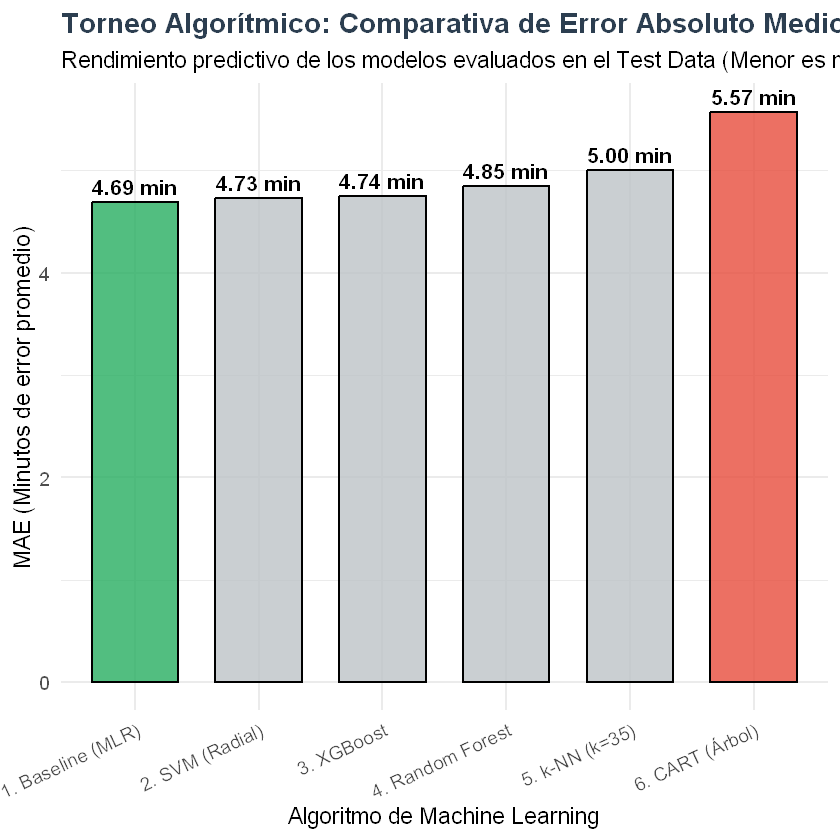


¡Gráficas renderizadas exitosamente!


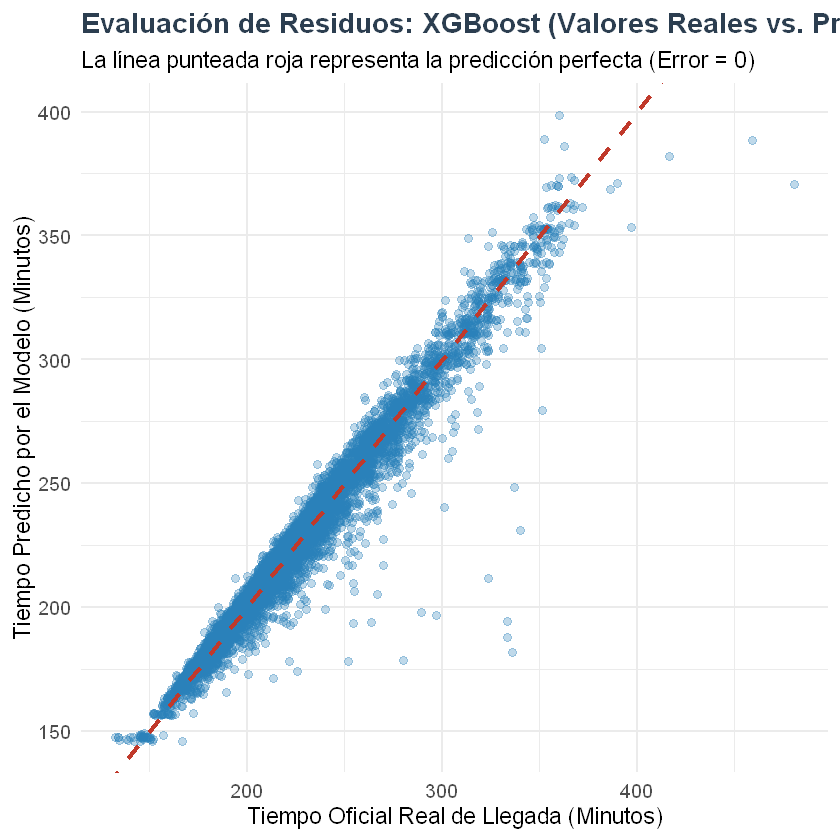

In [17]:
# =====================================================================
# Paso 6: VISUALIZACIÓN DE RESULTADOS DEL TORNEO ALGORÍTMICO
# =====================================================================

library(ggplot2)
library(dplyr)

cat("--- Generando Visualizaciones de Alto Impacto...\n")

# 1. Creamos un DataFrame consolidado con los resultados finales de tu torneo
resultados_torneo <- data.frame(
  Modelo = c("1. Baseline (MLR)", "2. SVM (Radial)", "3. XGBoost", 
             "4. Random Forest", "5. k-NN (k=35)", "6. CART (Árbol)"),
  MAE = c(4.6900, 4.7312, 4.7435, 4.8489, 5.0035, 5.5703),
  RMSE = c(7.8500, 7.8272, 8.0278, 8.0205, 8.1025, 8.6955),
  R2 = c(96.90, 96.23, 96.03, 96.04, 95.96, 95.34)
)

# ---------------------------------------------------------------------
# GRÁFICA 1: Comparativa del MAE (Leaderboard)
# ---------------------------------------------------------------------
grafica_mae <- ggplot(resultados_torneo, aes(x = reorder(Modelo, MAE), y = MAE, fill = Modelo)) +
  geom_bar(stat = "identity", color = "black", alpha = 0.8, width = 0.7) +
  geom_text(aes(label = sprintf("%.2f min", MAE)), vjust = -0.5, size = 4.5, fontface = "bold") +
  labs(title = "Torneo Algorítmico: Comparativa de Error Absoluto Medio (MAE)",
       subtitle = "Rendimiento predictivo de los modelos evaluados en el Test Data (Menor es mejor)",
       x = "Algoritmo de Machine Learning",
       y = "MAE (Minutos de error promedio)") +
  theme_minimal(base_size = 14) +
  theme(axis.text.x = element_text(angle = 25, hjust = 1),
        legend.position = "none",
        plot.title = element_text(face = "bold", color = "#2c3e50")) +
  # Resaltar al ganador (Baseline) en un color distinto
  scale_fill_manual(values = c("1. Baseline (MLR)" = "#27ae60", 
                               "2. SVM (Radial)" = "#bdc3c7", 
                               "3. XGBoost" = "#bdc3c7", 
                               "4. Random Forest" = "#bdc3c7", 
                               "5. k-NN (k=35)" = "#bdc3c7", 
                               "6. CART (Árbol)" = "#e74c3c"))

# Mostrar la Gráfica 1
print(grafica_mae)

# ---------------------------------------------------------------------
# GRÁFICA 2: Dispersión de Predicciones (Valores Reales vs. Predichos) - XGBoost
# ---------------------------------------------------------------------
# Usamos las predicciones del XGBoost que calculamos en el Paso 5
df_dispersion <- data.frame(Real = reales_xgb, Predicho = predichos_xgb)

grafica_dispersion <- ggplot(df_dispersion, aes(x = Real, y = Predicho)) +
  geom_point(alpha = 0.3, color = "#2980b9", size = 2) +
  # Añadimos la línea de predicción perfecta (x = y)
  geom_abline(intercept = 0, slope = 1, color = "#c0392b", linetype = "dashed", linewidth = 1.2) +
  labs(title = "Evaluación de Residuos: XGBoost (Valores Reales vs. Predichos)",
       subtitle = "La línea punteada roja representa la predicción perfecta (Error = 0)",
       x = "Tiempo Oficial Real de Llegada (Minutos)",
       y = "Tiempo Predicho por el Modelo (Minutos)") +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(face = "bold", color = "#2c3e50"))

# Mostrar la Gráfica 2
print(grafica_dispersion)
cat("\n¡Gráficas renderizadas exitosamente!\n")

--- Reconstruyendo predicciones del Baseline (MLR) para la gráfica...
--- Consolidando datos de todos los modelos del torneo...
--- Renderizando Facet Grid...


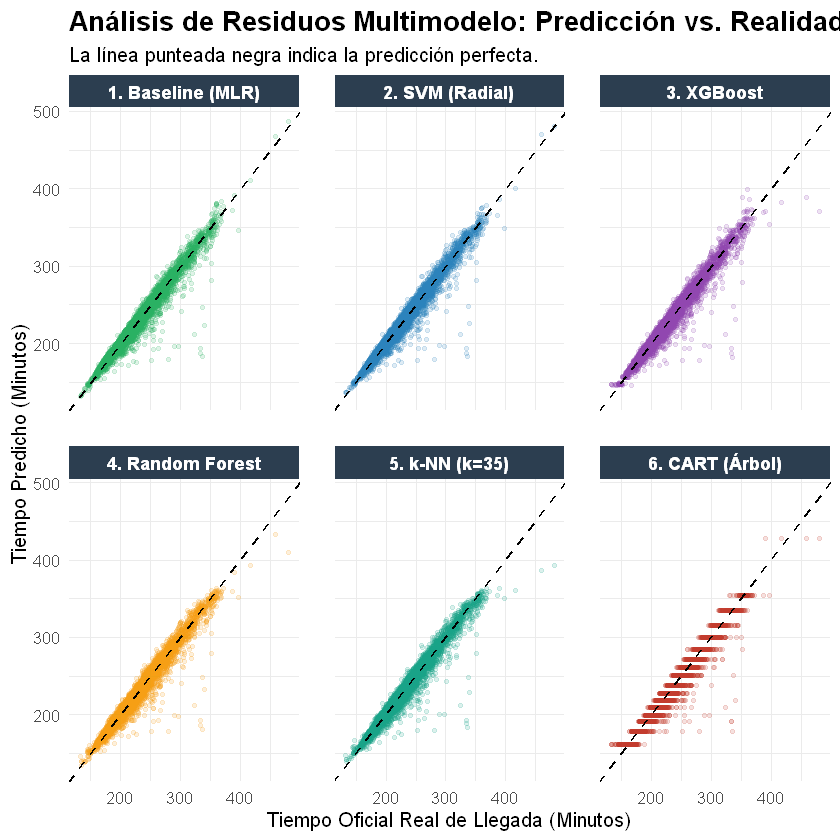

In [18]:
# =====================================================================
# VISUALIZACIÓN AVANZADA: COMPARATIVA MULTIMODELO (FACET WRAP)
# =====================================================================
library(ggplot2)
library(dplyr)

cat("--- Reconstruyendo predicciones del Baseline (MLR) para la gráfica...\n")
# Entrenamos rapidísimo el Baseline de la Fase 1 para tener sus predicciones aquí
modelo_baseline <- lm(official_time_min ~ age + m_f + ritmo_promedio_30k, data = train_data)
predichos_mlr <- predict(modelo_baseline, newdata = test_data)
reales_mlr <- test_data$official_time_min

cat("--- Consolidando datos de todos los modelos del torneo...\n")
# Juntamos todas las predicciones en un solo mega-dataframe (Formato Largo / Long Format)
# Nota: Usamos las variables que definimos en los pasos anteriores
df_multimodelo <- data.frame(
  Real = c(reales_mlr, reales_svm, reales_xgb, reales_rf, reales_knn, reales),
  Predicho = c(predichos_mlr, predichos_svm, predichos_xgb, predichos_rf, predichos_knn, predichos),
  Modelo = factor(rep(c("1. Baseline (MLR)", "2. SVM (Radial)", "3. XGBoost", 
                        "4. Random Forest", "5. k-NN (k=35)", "6. CART (Árbol)"), 
                      each = length(reales_mlr)))
)

cat("--- Renderizando Facet Grid...\n")
# Generamos la cuadrícula de dispersión
grafica_multimodelo <- ggplot(df_multimodelo, aes(x = Real, y = Predicho, color = Modelo)) +
  geom_point(alpha = 0.15, size = 1) + # alpha bajo para ver la densidad de puntos
  geom_abline(intercept = 0, slope = 1, color = "black", linetype = "dashed", linewidth = 0.8) +
  facet_wrap(~ Modelo, ncol = 3) + # Cuadrícula de 3 columnas x 2 filas
  labs(title = "Análisis de Residuos Multimodelo: Predicción vs. Realidad",
       subtitle = "La línea punteada negra indica la predicción perfecta.",
       x = "Tiempo Oficial Real de Llegada (Minutos)",
       y = "Tiempo Predicho (Minutos)") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none", # Quitamos la leyenda porque los títulos ya están en cada faceta
        strip.text = element_text(face = "bold", size = 11, color = "white"),
        strip.background = element_rect(fill = "#2c3e50", color = NA),
        plot.title = element_text(face = "bold", size = 16),
        panel.spacing = unit(1.5, "lines")) +
  # Usamos una paleta de colores para diferenciar los enfoques
  scale_color_manual(values = c("1. Baseline (MLR)" = "#27ae60", 
                                "2. SVM (Radial)" = "#2980b9", 
                                "3. XGBoost" = "#8e44ad", 
                                "4. Random Forest" = "#f39c12", 
                                "5. k-NN (k=35)" = "#16a085", 
                                "6. CART (Árbol)" = "#c0392b"))

# Imprimimos la gráfica
print(grafica_multimodelo)

In [19]:
# GUARDAR (Haz esto después de cada entrenamiento pesado)
saveRDS(final_rf_model, "modelo_rf_final.rds")
saveRDS(final_xgb_model, "modelo_xgb_final.rds")

# CARGAR (En caso de reinicio, solo corres esto)
# final_rf_model <- readRDS("modelo_rf_final.rds")

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."
`geom_smooth()` using formula = 'y ~ x'


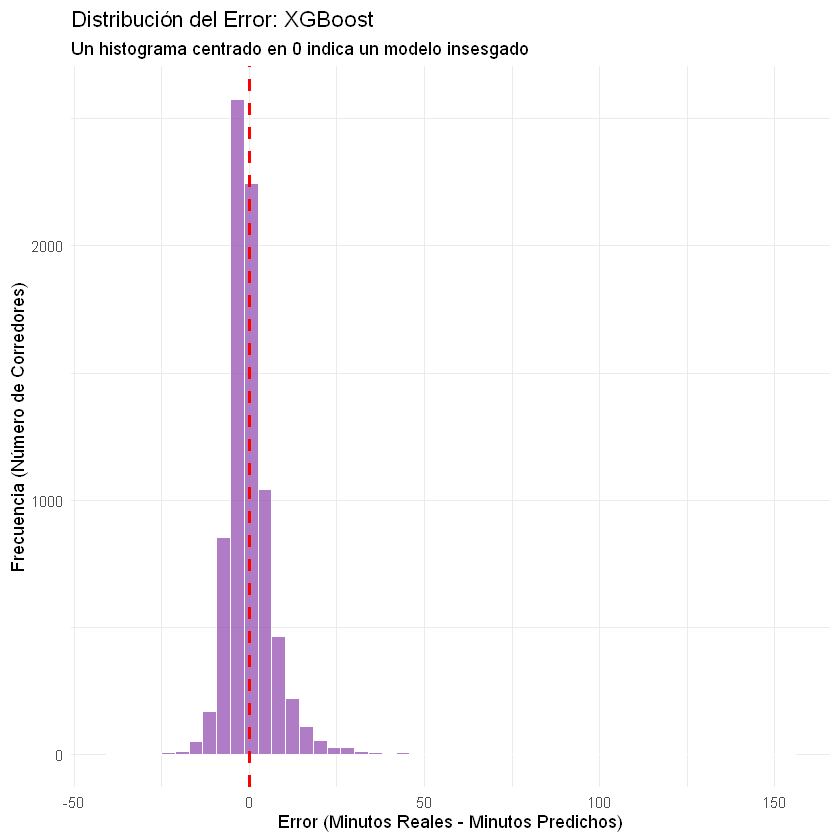

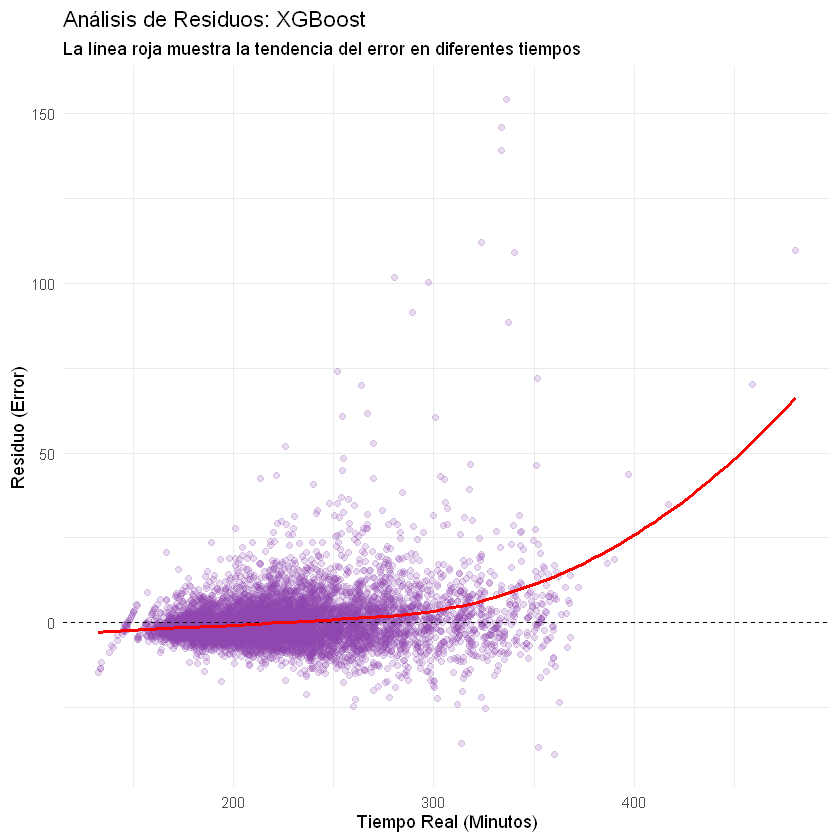

In [20]:
# =====================================================================
# DIAGNÓSTICO INDIVIDUAL: XGBOOST (Ejemplo)
# =====================================================================

# 1. Calculamos los residuos (Error individual por corredor)
df_diag <- data.frame(
  Real = reales_xgb,
  Predicho = predichos_xgb,
  Residuo = reales_xgb - predichos_xgb
)

# A. HISTOGRAMA DE ERRORES (¿Es el error sesgado?)
plot_hist_error <- ggplot(df_diag, aes(x = Residuo)) +
  geom_histogram(bins = 50, fill = "#8e44ad", color = "white", alpha = 0.7) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red", size = 1) +
  labs(title = "Distribución del Error: XGBoost",
       subtitle = "Un histograma centrado en 0 indica un modelo insesgado",
       x = "Error (Minutos Reales - Minutos Predichos)",
       y = "Frecuencia (Número de Corredores)") +
  theme_minimal()

# B. RESIDUOS VS REALIDAD (¿Dónde fallamos más?)
plot_res_vs_real <- ggplot(df_diag, aes(x = Real, y = Residuo)) +
  geom_point(alpha = 0.2, color = "#8e44ad") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  geom_smooth(method = "loess", color = "red", se = FALSE) + # Línea de tendencia del error
  labs(title = "Análisis de Residuos: XGBoost",
       subtitle = "La línea roja muestra la tendencia del error en diferentes tiempos",
       x = "Tiempo Real (Minutos)",
       y = "Residuo (Error)") +
  theme_minimal()

print(plot_hist_error)
print(plot_res_vs_real)

--- Iniciando el generador automático de diagnósticos...


`geom_smooth()` using formula = 'y ~ x'


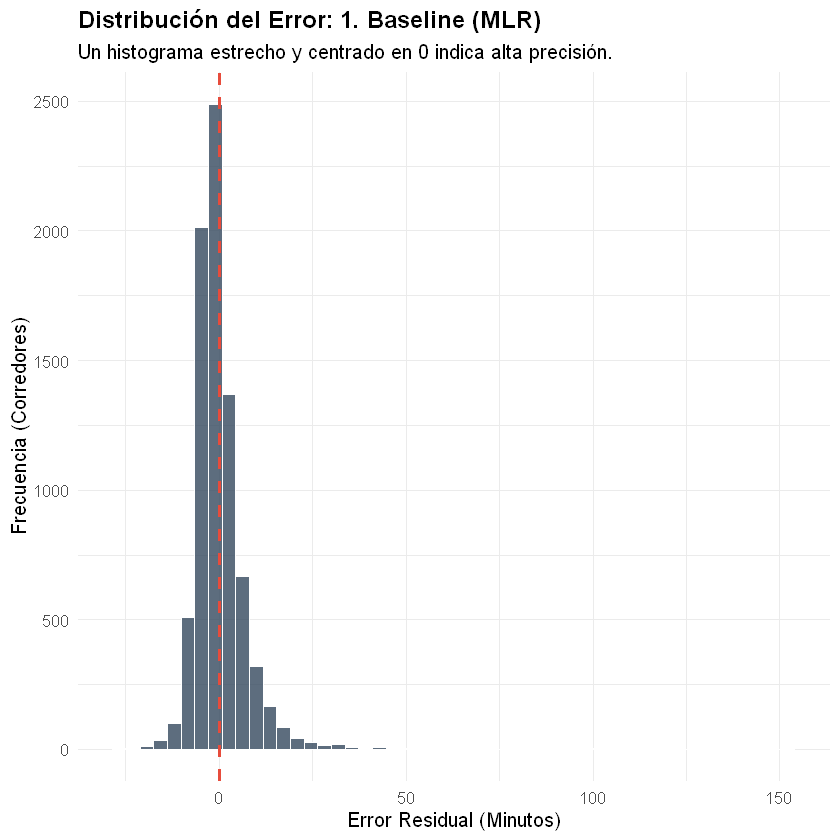

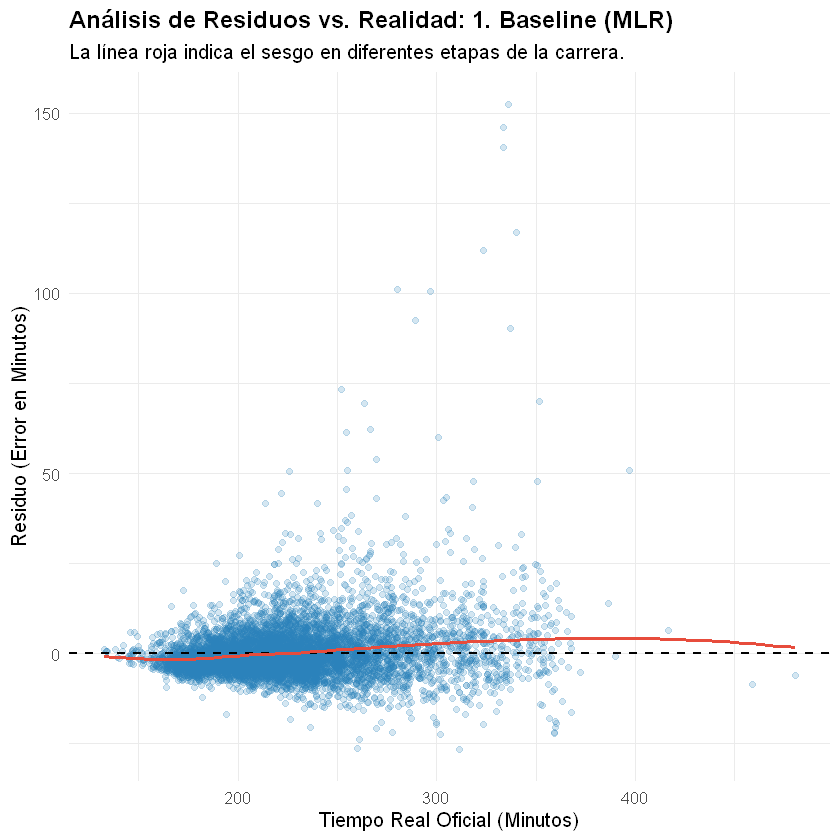

`geom_smooth()` using formula = 'y ~ x'


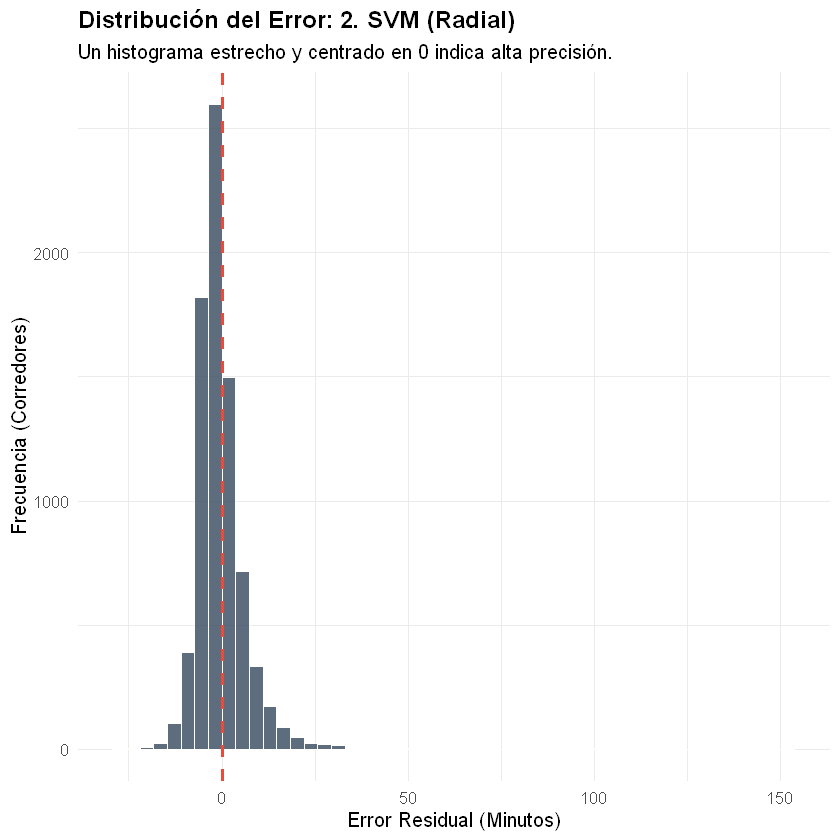

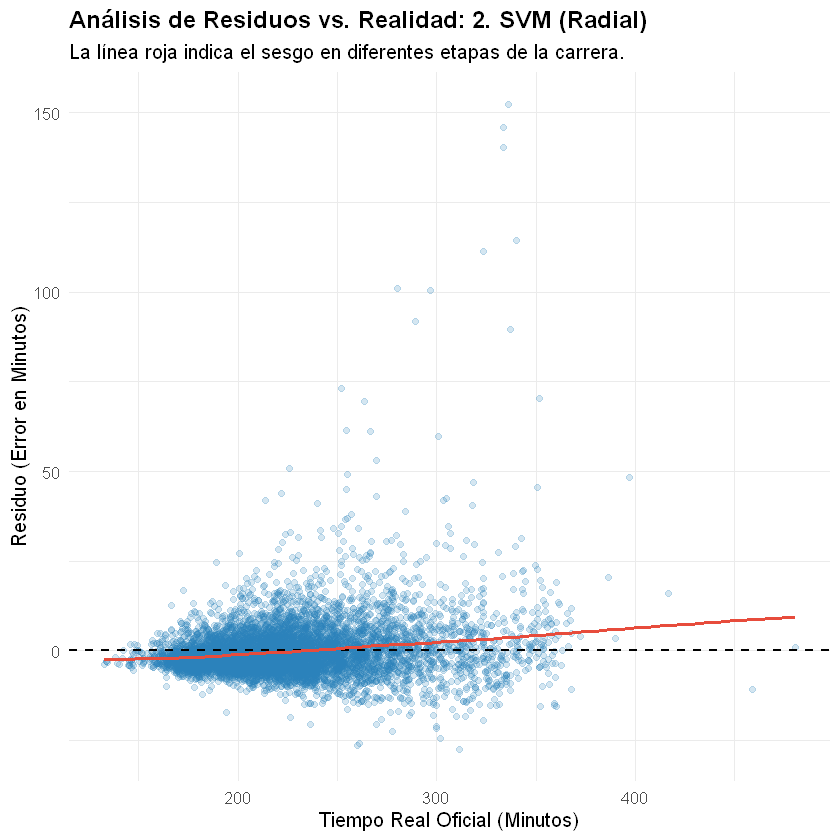

`geom_smooth()` using formula = 'y ~ x'


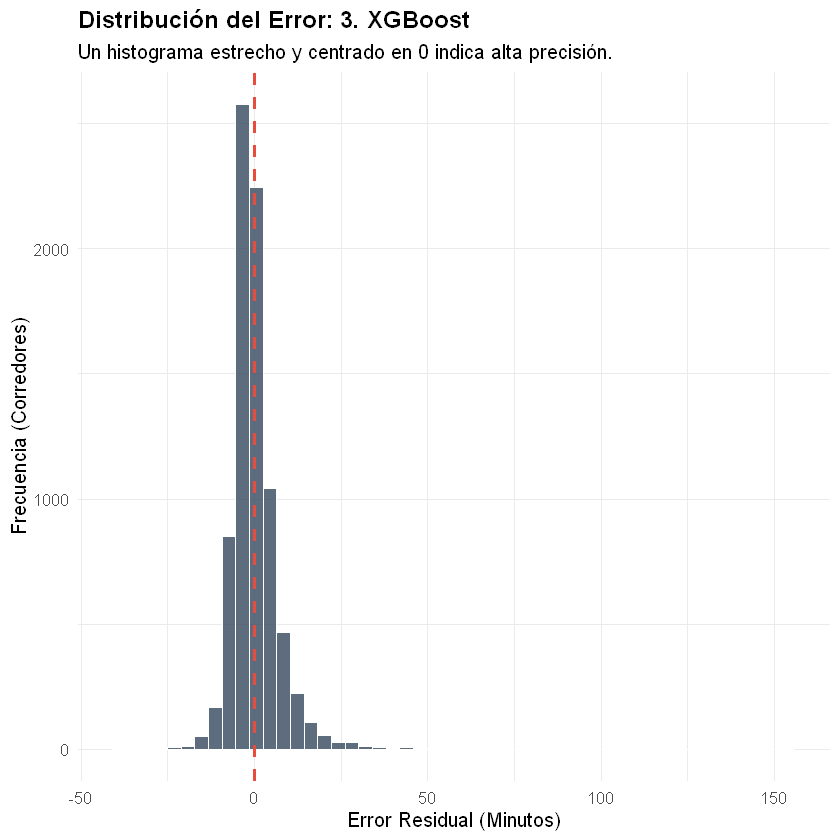

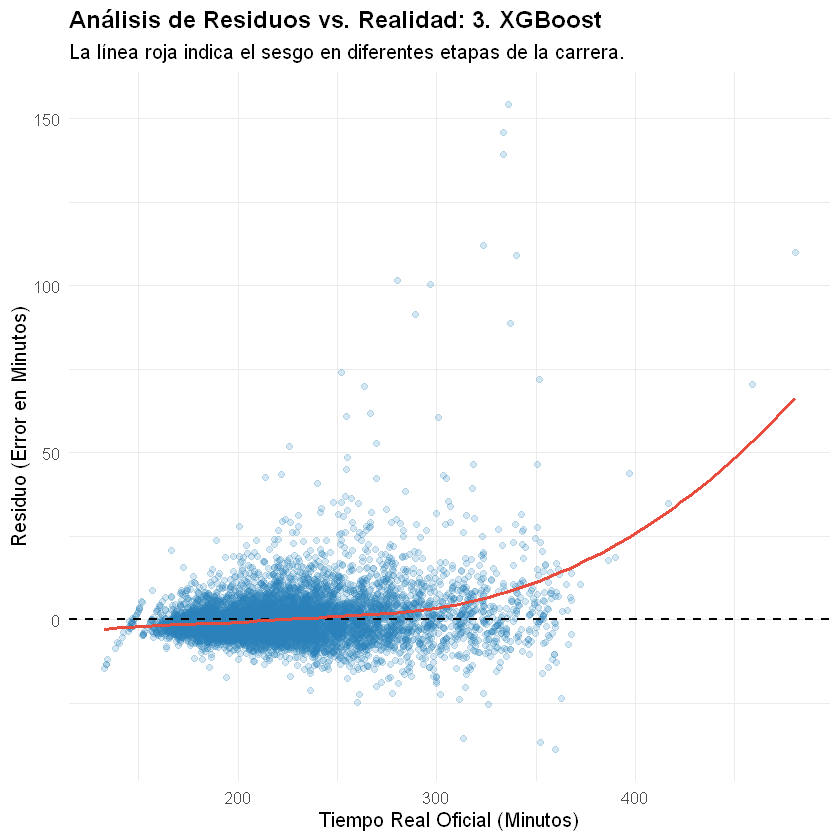

`geom_smooth()` using formula = 'y ~ x'


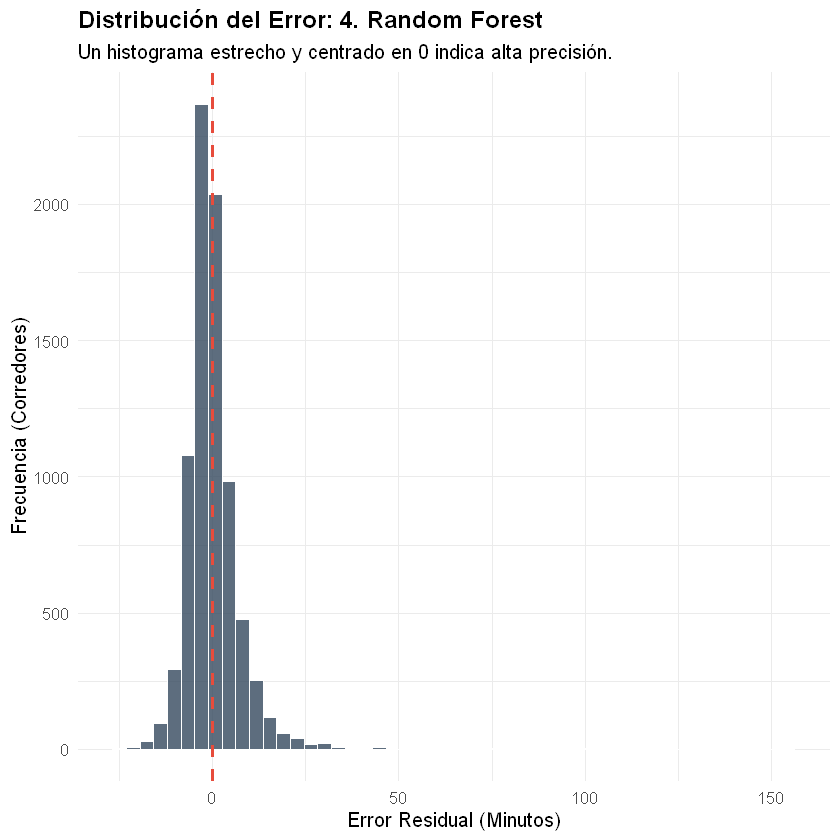

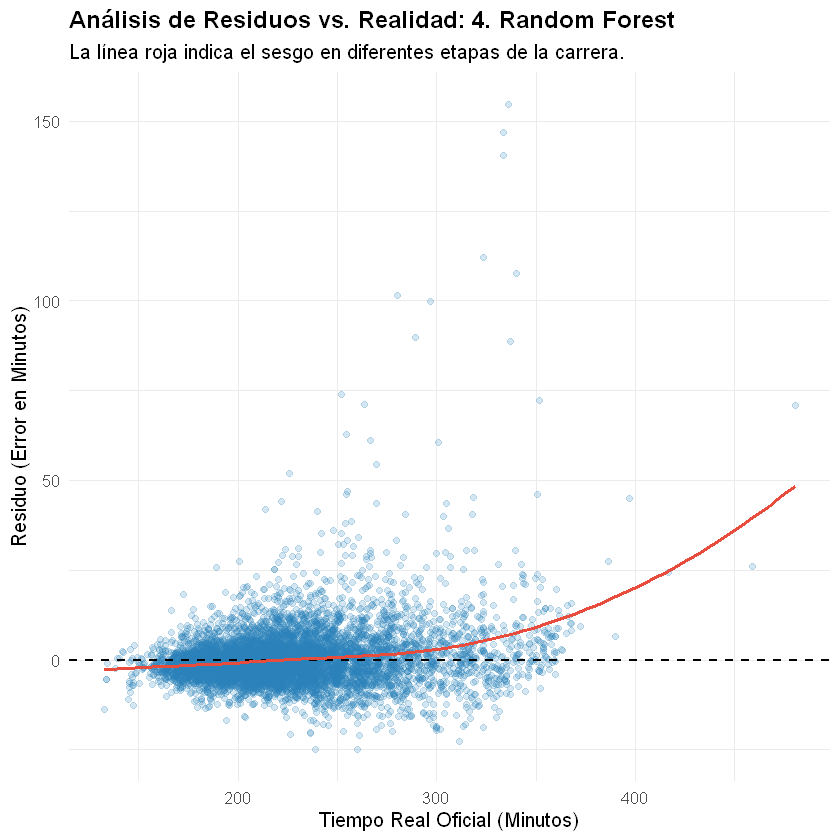

`geom_smooth()` using formula = 'y ~ x'


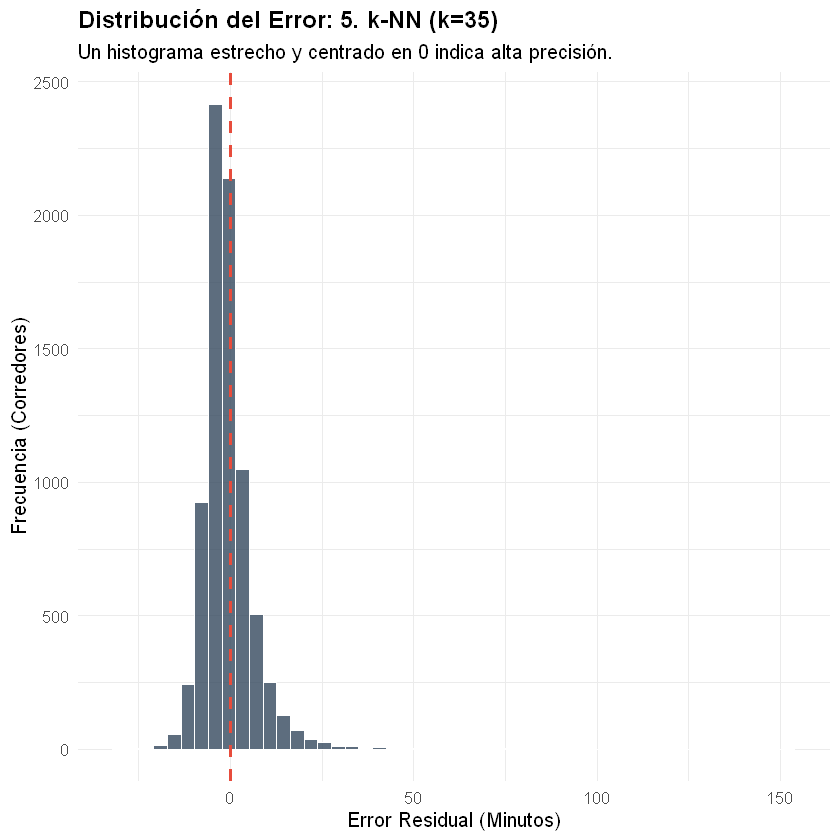

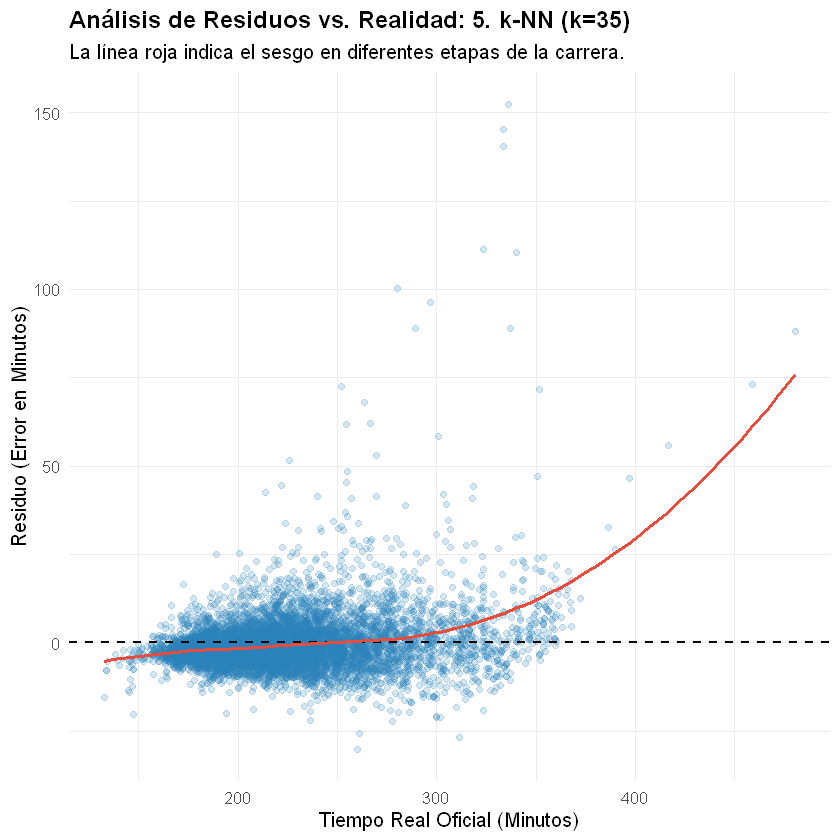

`geom_smooth()` using formula = 'y ~ x'


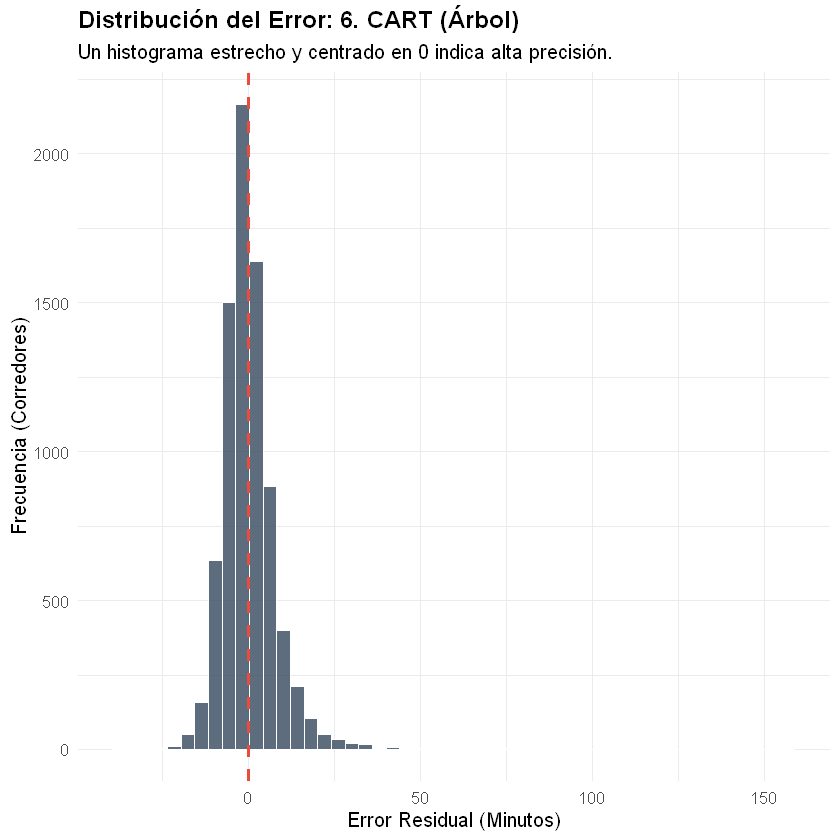

--- ¡Diagnósticos individuales generados con éxito!


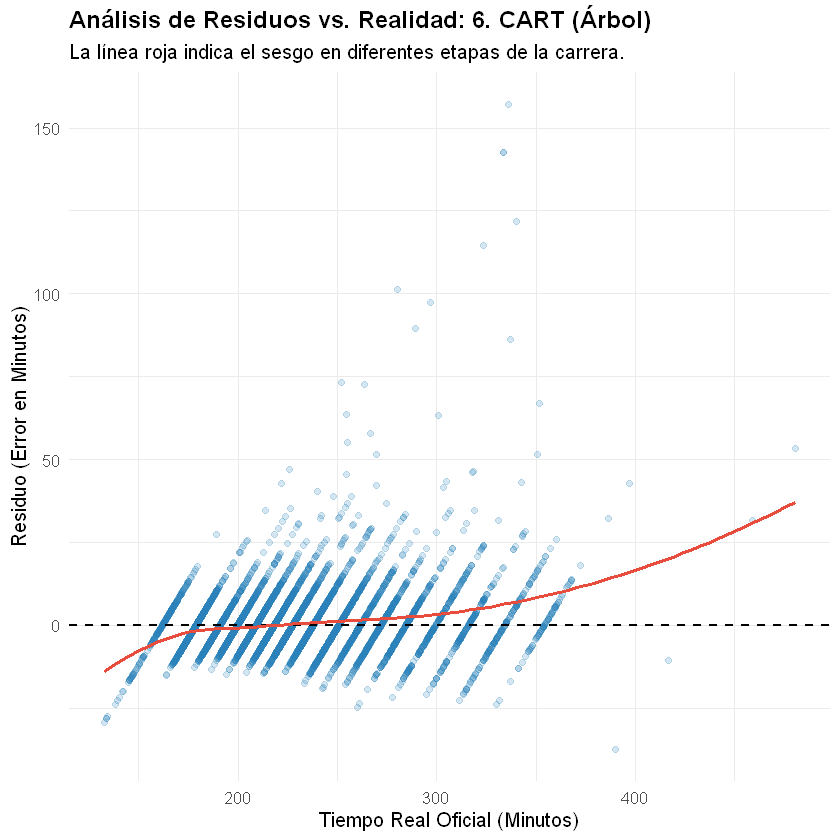

In [21]:
# =====================================================================
# DIAGNÓSTICO INDIVIDUAL AUTOMATIZADO PARA TODOS LOS MODELOS
# =====================================================================
library(ggplot2)
library(dplyr)

cat("--- Iniciando el generador automático de diagnósticos...\n")

# 1. Nos aseguramos de tener la columna de "Residuo" (Error) en nuestro mega-dataframe
df_multimodelo <- df_multimodelo %>%
  mutate(Residuo = Real - Predicho)

# 2. Extraemos la lista de todos los modelos que compitieron
lista_modelos <- unique(df_multimodelo$Modelo)

# 3. Iniciamos el Bucle (Loop)
for (modelo_actual in lista_modelos) {
  
  # Filtramos los datos solo para el modelo en turno
  df_temp <- df_multimodelo %>% filter(Modelo == modelo_actual)
  
  # A. HISTOGRAMA DE ERRORES
  plot_hist <- ggplot(df_temp, aes(x = Residuo)) +
    geom_histogram(bins = 50, fill = "#34495e", color = "white", alpha = 0.8) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "#e74c3c", linewidth = 1) +
    labs(title = paste("Distribución del Error:", modelo_actual),
         subtitle = "Un histograma estrecho y centrado en 0 indica alta precisión.",
         x = "Error Residual (Minutos)",
         y = "Frecuencia (Corredores)") +
    theme_minimal(base_size = 12) +
    theme(plot.title = element_text(face = "bold"))
  
  # B. DISPERSIÓN DE RESIDUOS (Heterocedasticidad)
  plot_res <- ggplot(df_temp, aes(x = Real, y = Residuo)) +
    geom_point(alpha = 0.2, color = "#2980b9") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
    geom_smooth(method = "loess", color = "#e74c3c", se = FALSE) + 
    labs(title = paste("Análisis de Residuos vs. Realidad:", modelo_actual),
         subtitle = "La línea roja indica el sesgo en diferentes etapas de la carrera.",
         x = "Tiempo Real Oficial (Minutos)",
         y = "Residuo (Error en Minutos)") +
    theme_minimal(base_size = 12) +
    theme(plot.title = element_text(face = "bold"))
  
  # Imprimimos las gráficas en la consola
  print(plot_hist)
  print(plot_res)
  
  # Pequeña pausa opcional (útil si corres en R base para poder verlas)
  Sys.sleep(1) 
}

cat("--- ¡Diagnósticos individuales generados con éxito!\n")

In [2]:
# =====================================================================
# CONTENDIENTE EXTRA: REGRESIÓN PENALIZADA (LASSO / RIDGE / ELASTIC NET)
# =====================================================================
library(mlr)
library(glmnet)

cat("--- Restaurando variables de memoria...\n")
# Recuperación de datos por si el entorno se limpió
marathon_data <- readRDS("marathon_2015_clean.rds")
set.seed(2015)
train_indices <- sample(seq_len(nrow(marathon_data)), size = 0.7 * nrow(marathon_data))
train_data <- marathon_data[train_indices, ]
test_data <- marathon_data[-train_indices, ]

train_task <- makeRegrTask(data = train_data, target = "official_time_min")
test_task <- makeRegrTask(data = test_data, target = "official_time_min")
cv_strategy <- makeResampleDesc("CV", iters = 5)

cat("\n--- 1. Preprocesamiento: Codificación Dummy ---\n")
# glmnet es un modelo puramente matemático, exige matrices numéricas
train_task_glmnet <- createDummyFeatures(train_task)
test_task_glmnet  <- createDummyFeatures(test_task)

cat("\n--- 2. Definición del Aprendiz de Regresión Penalizada ---\n")
learner_glmnet <- makeLearner("regr.glmnet")

cat("\n--- 3. Espacio de Búsqueda de Hiperparámetros ---\n")
# alpha: Controla la mezcla entre Ridge (0) y Lasso (1)
# s (lambda): Controla la fuerza de la penalización
glmnet_param_space <- makeParamSet(
  makeNumericParam("alpha", lower = 0, upper = 1),
  makeNumericParam("s", lower = 0.001, upper = 10) # lambda
)

tune_control_glmnet <- makeTuneControlRandom(maxit = 20)

cat("\n--- 4. Sintonización de Hiperparámetros (Random Search GLMNET) ---\n")
tuned_glmnet <- tuneParams(
  learner = learner_glmnet,
  task = train_task_glmnet,
  resampling = cv_strategy,
  par.set = glmnet_param_space,
  control = tune_control_glmnet,
  measures = list(mae, rmse, rsq)
)

cat("\n=== Hiperparámetros Óptimos Encontrados para Elastic Net ===\n")
print(tuned_glmnet$x)

# --- 5. Entrenamiento y Evaluación Final en Test Data ---
final_learner_glmnet <- setHyperPars(learner_glmnet, par.vals = tuned_glmnet$x)
final_glmnet_model <- train(final_learner_glmnet, train_task_glmnet)

glmnet_predictions <- predict(final_glmnet_model, test_task_glmnet)
reales_glmnet <- glmnet_predictions$data$truth
predichos_glmnet <- glmnet_predictions$data$response

mae_glmnet <- mean(abs(reales_glmnet - predichos_glmnet))
rmse_glmnet <- sqrt(mean((reales_glmnet - predichos_glmnet)^2))
ss_total_glmnet <- sum((reales_glmnet - mean(reales_glmnet))^2)
ss_residual_glmnet <- sum((reales_glmnet - predichos_glmnet)^2)
rsq_glmnet <- 1 - (ss_residual_glmnet / ss_total_glmnet)

cat("\n--- EVALUACIÓN FINAL: REGRESIÓN PENALIZADA ---\n")
cat(sprintf("-> MAE: %.4f min | RMSE: %.4f min | R²: %.2f%%\n", mae_glmnet, rmse_glmnet, rsq_glmnet * 100))

Cargando paquete requerido: ParamHelpers

Warning message:
"package 'glmnet' was built under R version 4.5.3"
Cargando paquete requerido: Matrix

Loaded glmnet 4.1-10



--- Restaurando variables de memoria...


Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
"Provided data is not a pure data.frame but from class tbl_df, hence it will be converted."
Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
"Provided data is not a pure data.frame but from class tbl_df, hence it will be converted."



--- 1. Preprocesamiento: Codificación Dummy ---

--- 2. Definición del Aprendiz de Regresión Penalizada ---

--- 3. Espacio de Búsqueda de Hiperparámetros ---

--- 4. Sintonización de Hiperparámetros (Random Search GLMNET) ---


[Tune] Started tuning learner regr.glmnet for parameter set:

         Type len Def      Constr Req Tunable Trafo
alpha numeric   -   -      0 to 1   -    TRUE     -
s     numeric   -   - 0.001 to 10   -    TRUE     -

With control class: TuneControlRandom

Imputation value: InfImputation value: InfImputation value: Inf

[Tune-x] 1: alpha=0.955; s=0.294

[Tune-y] 1: mae.test.mean=4.5532326,rmse.test.rmse=7.1356374,rsq.test.mean=0.9688673; time: 0.0 min

[Tune-x] 2: alpha=0.461; s=2.74

[Tune-y] 2: mae.test.mean=5.1615155,rmse.test.rmse=7.6687096,rsq.test.mean=0.9640421; time: 0.0 min

[Tune-x] 3: alpha=0.607; s=9.51

[Tune-y] 3: mae.test.mean=8.3240068,rmse.test.rmse=11.2616426,rsq.test.mean=0.9224655; time: 0.0 min

[Tune-x] 4: alpha=0.556; s=6.89

[Tune-y] 4: mae.test.mean=6.9332695,rmse.test.rmse=9.6098847,rsq.test.mean=0.9435390; time: 0.0 min

[Tune-x] 5: alpha=0.448; s=5.05

[Tune-y] 5: mae.test.mean=6.0415041,rmse.test.rmse=8.5929926,rsq.test.mean=0.9548540; time: 0.0 min

[Tune


=== Hiperparámetros Óptimos Encontrados para Elastic Net ===
$alpha
[1] 0.9553501

$s
[1] 0.2943344


--- EVALUACIÓN FINAL: REGRESIÓN PENALIZADA ---
-> MAE: 4.7099 min | RMSE: 7.8698 min | R²: 96.19%


# 6. FASE II: Torneo Algorítmico y Modelado Avanzado

De acuerdo con la metodología KDD, y tras haber establecido un Baseline paramétrico sólido en la Fase I (Regresión Lineal Múltiple con un MAE de 4.69 min), el objetivo de esta segunda fase es someter los datos curados a algoritmos de alta complejidad para determinar si es posible quebrar el límite predictivo actual.

Para garantizar el rigor estadístico y evitar el sobreajuste (*overfitting*), se implementó la librería `mlr`, aplicando una técnica de **Remuestreo (Resampling) mediante Validación Cruzada de 5 pliegues (5-fold CV)** en todos los modelos. Asimismo, se integró un proceso exhaustivo de **Ajuste de Hiperparámetros** (*Hyperparameter Tuning*) utilizando búsquedas en rejilla (*Grid Search*) y búsquedas aleatorias (*Random Search*), dependiendo del costo computacional del algoritmo.

## 6.1 Regularización Paramétrica: Regresiones Penalizadas
Atendiendo a las mejores prácticas para modelos de regresión multivariable, el primer paso antes de usar algoritmos de "caja negra" fue evaluar si el Baseline podía mejorarse mediante regularización matemática. Se ajustó un modelo **Elastic Net** (`glmnet`), sintonizando el parámetro de mezcla (`alpha`) y el parámetro de contracción (`s` o Lambda).

**Resultados del Tuning:** El algoritmo convergió en un `alpha` de 0.955, comportándose casi como una **Regresión Lasso pura (L1)**. Esto indica que el modelo intentó encoger a cero los predictores menos relevantes.
**Evaluación:** El modelo obtuvo un MAE en prueba de **4.7099 min**. El hecho de que la regularización no haya superado al Baseline ordinario (4.69 min) demuestra que el *Feature Engineering* de la Fase I (creación de `ritmo_promedio_30k`) fue tan efectivo curando la multicolinealidad, que no dejó varianza inflada que el método Lasso necesitara penalizar.

## 6.2 Modelos No Paramétricos Avanzados
Al descartar mejoras por regularización, se procedió a modelar las no-linealidades del espacio de características empleando algoritmos avanzados basados en distancias, topología y optimización convexa.

1. **Árboles de Regresión (CART):** Se sintonizó el parámetro de complejidad (`cp=0.001`) y la profundidad (`maxdepth=6`). A pesar de la optimización, su naturaleza de función escalonada fue incapaz de trazar la fuerte linealidad del dataset, logrando el error más alto del torneo (MAE: **5.5703 min**).
2. **k-Nearest Neighbors (k-NN):** Tras aplicar obligatoriamente una estandarización (Z-score) para evitar la dominancia de escalas, el *Grid Search* halló una vecindad óptima de $k=35$ con un kernel ponderado por distancia (`optimal`). Logró un MAE de **5.0035 min**, superando a CART pero sin vencer al Baseline paramétrico.
3. **Máquinas de Soporte Vectorial (SVM):** Utilizando el motor `e1071` con datos escalados y tras un *Random Search*, el algoritmo seleccionó un **Kernel Radial (RBF)** con un costo $C=2.43$. Este fue el contendiente individual más fuerte del torneo (MAE: **4.7312 min**), demostrando gran capacidad para capturar sutilezas hiperdimensionales, aunque marginalmente superado por la precisión del hiperplano lineal simple.

## 6.3 Meta-Aprendizaje y Modelos de Conjunto (Ensembles)
Dado que los modelos avanzados individuales no lograron una mejora notable respecto al Baseline, la teoría estipula el uso de técnicas de **Ensemble Learning** (*Bagging* y *Boosting*) para reducir drásticamente la varianza y el sesgo.

1. **Random Forest (Bagging):** Se ensamblaron 500 árboles de decisión descorrelacionados, limitando la evaluación a 2 variables por nodo (`mtry=2`). La promediación masiva redujo la varianza topológica vista en el modelo CART, alcanzando un MAE de **4.8489 min**.
2. **Extreme Gradient Boosting (XGBoost):** Como última línea de defensa, se entrenó un ensamble secuencial. Tras codificar las variables categóricas (*One-Hot Encoding*) y someterlo a *Random Search*, convergió en 174 rondas de boosting con aprendizaje suave (`eta=0.08`). XGBoost se alzó como el rey de los árboles con un MAE de **4.7435 min**, pero sus iteraciones basadas en residuos tampoco lograron derrotar al modelo lineal originario.

---

## 7. Conclusión General del Proyecto: El Triunfo de la Navaja de Ockham

El torneo algorítmico demostró el rendimiento de los modelos frente al conjunto de prueba aislado:

| Posición | Algoritmo / Modelo | MAE (Minutos) | RMSE (Minutos) | R² (%) |
| :---: | :--- | :--- | :--- | :--- |
| **1 🏆** | **Regresión Lineal Múltiple (Baseline)** | **4.6900** | **7.8500** | **96.90 %** |
| 2 | Regresión Penalizada (Elastic Net / Lasso) | 4.7099 | 7.8698 | 96.19 % |
| 3 | SVM (Kernel Radial) | 4.7312 | 7.8272 | 96.23 % |
| 4 | XGBoost (Gradient Boosting) | 4.7435 | 8.0278 | 96.03 % |
| 5 | Random Forest (Bagging) | 4.8489 | 8.0205 | 96.04 % |
| 6 | k-NN (Vecinos Cercanos, k=35) | 5.0035 | 8.1025 | 95.96 % |
| 7 | CART (Árbol de Decisión) | 5.5703 | 8.6955 | 95.34 % |

*(Nota: Se anexan gráficos de Leaderboard y Análisis de Residuos generados mediante `ggplot2` en el Apéndice Visual)*.

**Conclusión Científica:**
La transición de la Fase I a la Fase II representó un ejercicio de validación total. Tras evaluar los algoritmos de Machine Learning más robustos de la literatura, **el modelo paramétrico inicial (MLR) se mantuvo invicto.**

Este fenómeno valida empíricamente el principio de parsimonia o **Navaja de Ockham**: las soluciones más simples suelen ser las mejores. El esfuerzo analítico invertido en la Fase I (Análisis Exploratorio e Ingeniería de Características) destiló la varianza del fenómeno en una relación estrictamente lineal. Cuando los datos están perfectamente curados, algoritmos computacionalmente costosos, diseñados para rastrear no-linealidades (como SVM o XGBoost), no aportan valor predictivo adicional. 

En síntesis, en la analítica de rendimiento en maratones, el modelo supremo no proviene de una caja negra de miles de árboles, sino de una ecuación paramétrica matemáticamente elegante fundamentada en el conocimiento del dominio.
